# **NLP Project - Biomedical Information Retrieval**

**Phase 2: Factually Grounded RAG — Cross-Encoder Re-Ranking · Transformer Internals · Answer Generation · LLM-as-a-Judge**

## TODO / Duvidas:
» confirmar estamos a usar o melhor mdelo da phase 1 para retrieving 
» resposta de 250 words é hard constraint ou soft? (atualmente temos soft no codigo)

» confirmar que modelos é pra usar como vLLM... estamos a usar o gpt4 do iaedu como judge... confirmar como é gerador, etc... 
rever  codigo todo devagar pra confirmar os modelos a usar e endpoints, formats, etc... 

»

---

## Index

- [**0. Project Set Up**](#0-project-set-up)
  - [0.1. Constants & Config](#01-constants--config)
  - [0.2. Colab / Local Setup](#02-colab--local-setup)
  - [0.3. Imports](#03-imports)
  - [0.4. Data Loading](#04-data-loading)
  - [0.5. Phase 1 Locked Configuration Recap](#05-phase-1-locked-configuration-recap)
- [**1. Cross-Encoder Re-Ranking**](#1-cross-encoder-re-ranking)
  - [1.1. Bi-Encoder vs Cross-Encoder](#11-bi-encoder-vs-cross-encoder)
  - [1.2. Load Cross-Encoder](#12-load-cross-encoder)
  - [1.3. Sentence Segmentation](#13-sentence-segmentation)
  - [1.4. Sentence Scoring Demo](#14-sentence-scoring-demo)
  - [1.5. Score Distribution Analysis](#15-score-distribution-analysis)
  - [1.6. Ablation: Random vs Cross-Encoder Selection](#16-ablation-random-vs-cross-encoder-selection)
- [**2. Transformer Internals: Embeddings & Attention**](#2-transformer-internals-embeddings--attention)
  - [2.1. Model Setup for Analysis](#21-model-setup-for-analysis)
  - [2.2. Positional Embeddings — Distance from Token 0](#22-positional-embeddings--distance-from-token-0)
  - [2.3. Pairwise Distance Matrix](#23-pairwise-distance-matrix)
  - [2.4. Contextual Embeddings — Layer-by-Layer Evolution](#24-contextual-embeddings--layer-by-layer-evolution)
  - [2.5. Self-Attention Analysis](#25-self-attention-analysis)
- [**3. Answer Generation**](#3-answer-generation)
  - [3.1. RAG Pipeline Design](#31-rag-pipeline-design)
  - [3.2. LLM Client Setup](#32-llm-client-setup)
  - [3.3. Context Formatting](#33-context-formatting)
  - [3.4. Prompt Design](#34-prompt-design)
  - [3.5. Generation + Parsing Demo](#35-generation--parsing-demo)
  - [3.6. Constraint Violation Analysis](#36-constraint-violation-analysis)
  - [3.7. Bulk Answer Generation — Training Set](#37-bulk-answer-generation--training-set)
- [**4. LLM-as-a-Judge Evaluation**](#4-llm-as-a-judge-evaluation)
  - [4.1. Motivation: Why LLM Judges?](#41-motivation-why-llm-judges)
  - [4.2. Judge Prompt Design — Sentence Alignment](#42-judge-prompt-design--sentence-alignment)
  - [4.3. Judge Prompt Design — Answer Entailment](#43-judge-prompt-design--answer-entailment)
  - [4.4. Prompt Calibration on Manual Sample](#44-prompt-calibration-on-manual-sample)
  - [4.5. Bulk Sentence Alignment — Training Set](#45-bulk-sentence-alignment--training-set)
  - [4.6. Bulk Answer Entailment — Training Set](#46-bulk-answer-entailment--training-set)
  - [4.7. Correlation: Retrieval Quality → Answer Quality](#47-correlation-retrieval-quality--answer-quality)
  - [4.8. Error Analysis — Failure Cases](#48-error-analysis--failure-cases)
- [**5. Test Set Evaluation & Summary**](#5-test-set-evaluation--summary)
  - [5.1. Test Set Generation + Judging](#51-test-set-generation--judging)
  - [5.2. Final Results Tables](#52-final-results-tables)
  - [5.3. (Optional) vLLM vs GPT-4o Generator Comparison](#53-optional-vllm-vs-gpt-4o-generator-comparison)
  - [5.4. Phase 2 Summary & Locked Config for Phase 3](#54-phase-2-summary--locked-config-for-phase-3)

---

**About the Code:**

> All logic lives in `src/`. This notebook calls the src python files, reusable across tasks.

**AI Assistance Disclosure**

> AI tools (Claude, GitHub Copilot) were used for debugging, testing, and formatting.
> All core concepts, architecture decisions, and methodology were conceived by the authors.

---
## 0. Project Set Up

Phase 2 builds on the locked retrieval configuration from Phase 1.
We load the same corpus, topics, qrels, and best Phase 1 run, then add:
- Cross-encoder re-ranking of retrieved sentences
- Transformer embedding/attention analysis
- LLM-based answer generation with citations
- LLM-as-a-Judge evaluation (sentence alignment + answer entailment)

---
### 0.1 Constants & Config

All Phase 2 constants in one place. Grouped by:
- **Flags** — toggle heavy operations (re-run generation, re-run judging)
- **Retrieval config** — locked from Phase 1 best
- **Cross-encoder** — model and sentence selection settings
- **Generation** — vLLM and GPT-4o endpoints, prompt parameters
- **Judge** — same GPT-4o for both generation and judging
- **Output paths** — where Phase 2 results are saved

In [ ]:
from pathlib import Path

# ── Phase 2 flags ────────────────────────────────────────────────────────────
FORCE_RERUN_GENERATION  = False   # skip if results/phase2/train_answers.json exists
FORCE_RERUN_JUDGING     = False   # skip if judge result files exist

# ── Retrieval config (locked from Phase 1) ────────────────────────────────────
P2_RETRIEVER            = "KNN(MedCPT)"    # Phase 1 best strategy
BEST_QUERY_FIELD        = "topic+question"  # Phase 1 ablation winner
P2_RETRIEVAL_TOP_K      = 10               # top-k docs to feed into re-ranker

# ── Encoder model tuples — same definitions as Phase 1 ──────────────────────
ENCODER_MED_CPT  = ("medcpt", "ncbi/MedCPT-Query-Encoder", 768)
ENCODER_BEST     = ENCODER_MED_CPT

# ── Cross-encoder config ────────────────────────────────────────────────────
CROSS_ENCODER_MODEL     = "ncbi/MedCPT-Cross-Encoder"
TOP_SENTENCES_PER_DOC   = 3                # keep top-3 sentences per document

# ── Generation config ────────────────────────────────────────────────────────
VLLM_URL                = "https://amalia.novasearch.org/vlm/v1"
VLLM_KEY                = "amalia012026"
GENERATION_TEMPERATURE  = 0.1
MAX_ANSWER_WORDS        = 250
MAX_PMIDS_PER_SENTENCE  = 3

# ── Judge / Primary LLM config (GPT-4o for both generation and judging) ────
# Keys are loaded from environment variables in the setup cell.
# IAEDU_URL and IAEDU_KEY will be read from .env or Colab Secrets.
GPT4O_MODEL             = "gpt-4o"

# ── Data files (same as Phase 1) ────────────────────────────────────────────
CORPUS_FILE             = "data/filtered_pubmed_abstracts.txt"
TOPICS_FILE             = "data/BioGen2024topics.json"
SUBMISSIONS_FILE        = "data/biogen_2024_submissions.json"

# ── Phase 1 result files ────────────────────────────────────────────────────
PHASE1_BEST_RUN_FILE    = "results/knn_best_test_run.json"
PHASE1_BEST_TRAIN_RUN   = "results/knn_train_run.json"
PHASE1_EVAL_SUMMARY     = "results/final_eval_summary.json"

# ── Qrels (same as Phase 1) ─────────────────────────────────────────────────
QRELS_BINARY_FILE       = "results/qrels/qrels.json"
QRELS_GRADED_FILE       = "results/qrels/qrels_graded.json"
SPLITS_DIR              = "results/splits"

# ── Output paths ─────────────────────────────────────────────────────────────
# ROOT will be set in the setup cell below.
# These are relative; will be joined with ROOT after setup.
_PHASE2_DIR_REL          = "results/phase2"
_PHASE2_FIGURES_REL      = "results/phase2/figures"

print("Phase 2 constants defined.")

Phase 2 constants defined.


---
### 0.2 Colab / Local Setup

Identical pattern to Phase 1: clone repo in Colab, load `.env` locally, enable autoreload, resolve `ROOT`.

**Phase 2 additions:** also load `IAEDU_URL`, `IAEDU_KEY` from Colab Secrets / `.env` for GPT-4o access,
and `VLLM_URL`, `VLLM_KEY` for vLLM access.

In [25]:
import sys
import os
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    # -- clone / update the repo --
    if not os.path.exists("/content/nlp-biomedical-agent"):
        os.system("git clone https://github.com/fmssilva/NLP_BioMedical_Agent.git /content/nlp-biomedical-agent")
    else:
        os.system("git -C /content/nlp-biomedical-agent pull --ff-only")
    os.chdir("/content/nlp-biomedical-agent")
    os.system("pip install -r requirements.txt -q")

    # -- credentials via Colab Secrets (Secrets panel in the left sidebar) --
    from google.colab import userdata
    _all_keys = [
        # Phase 1: OpenSearch
        "OPENSEARCH_HOST", "OPENSEARCH_PORT", "OPENSEARCH_USER", "OPENSEARCH_PASS", "OPENSEARCH_INDEX",
        # Phase 2: GPT-4o via IAedu + vLLM
        "IAEDU_URL", "IAEDU_KEY", "VLLM_URL", "VLLM_KEY",
    ]
    for _key in _all_keys:
        try:
            os.environ[_key] = userdata.get(_key)
        except userdata.SecretNotFoundError:
            pass

    _missing = [k for k in ["OPENSEARCH_USER", "OPENSEARCH_PASS", "OPENSEARCH_INDEX"] if not os.getenv(k)]
    if _missing:
        raise EnvironmentError(
            f"Missing Colab Secrets: {_missing}\n"
            "Colab sidebar > Secrets > add and enable them, then re-run this cell."
        )

else:
    # -- local: .env file at project root (never committed to git, see .gitignore) --
    from dotenv import load_dotenv
    _cwd = Path(os.getcwd()).resolve()
    for _parent in [_cwd, _cwd.parent, _cwd.parent.parent]:
        _env = _parent / ".env"
        if _env.exists():
            load_dotenv(_env)
            break

    # enable autoreload so edits to src/ reflect immediately without re-running the kernel
    from IPython import get_ipython
    _ipy = get_ipython()
    if _ipy:
        _ipy.run_line_magic("load_ext", "autoreload")
        _ipy.run_line_magic("autoreload", "2")

# ── Resolve project root (works for both local and Colab) ────────────────────
# NOTE: the notebook lives in tasks/
ROOT = Path(os.getcwd()).resolve()
for _p in [ROOT, ROOT.parent]:
    if (_p / "requirements.txt").exists():
        ROOT = _p
        break

# Add project root to sys.path AFTER ROOT correction
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Purge any stale 'src' module cached from a different project (shared kernel)
_our_src = str(ROOT / "src")
if "src" in sys.modules and _our_src not in getattr(sys.modules["src"], "__path__", []):
    _stale = [k for k in sys.modules if k == "src" or k.startswith("src.")]
    for k in _stale:
        del sys.modules[k]

# ── Resolve Phase 2 output paths (now that ROOT is known) ───────────────────
PHASE2_DIR           = ROOT / _PHASE2_DIR_REL
PHASE2_FIGURES_DIR   = ROOT / _PHASE2_FIGURES_REL
TRAIN_ANSWERS_FILE   = PHASE2_DIR / "train_answers.json"
TEST_ANSWERS_FILE    = PHASE2_DIR / "test_answers.json"
SENTENCE_ALIGN_TRAIN = PHASE2_DIR / "sentence_alignment_train.json"
SENTENCE_ALIGN_TEST  = PHASE2_DIR / "sentence_alignment_test.json"
ENTAILMENT_TRAIN     = PHASE2_DIR / "entailment_train.json"
ENTAILMENT_TEST      = PHASE2_DIR / "entailment_test.json"

# Ensure output directories exist
PHASE2_DIR.mkdir(parents=True, exist_ok=True)
PHASE2_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ── Connect to OpenSearch (needed for live retrieval demo) ───────────────────
from src.indexing.opensearch_client import get_client, check_index

client     = get_client()
index_name = os.getenv("OPENSEARCH_INDEX", "")
assert index_name, "OPENSEARCH_INDEX not set — check .env (local) or Colab Secrets (Colab)"

print(f"Project root     : {ROOT}")
print(f"In Colab         : {IN_COLAB}")
print(f"Index name       : {index_name}")
print(f"Phase 2 results  : {PHASE2_DIR}")

check_index(client, index_name)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Project root     : C:\Users\franc\Desktop\NLP_Biomedical_Agent
In Colab         : False
Index name       : usernlp03
Phase 2 results  : C:\Users\franc\Desktop\NLP_Biomedical_Agent\results\phase2
[index] 'usernlp03'  docs=4194  [ok] fully populated
[index] 'usernlp03'  docs=4194  [ok] fully populated


True

---
### 0.3 Imports

All imports for Phase 2 in one cell. GPU check and NLTK data download included.

In [10]:
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from tqdm.auto import tqdm

# ── GPU check ────────────────────────────────────────────────────────────────
if torch.cuda.is_available():
    print(f"GPU available  : {torch.cuda.get_device_name(0)}")
    print(f"CUDA version   : {torch.version.cuda}")
else:
    print("GPU available  : No — running on CPU")

print(f"PyTorch version: {torch.__version__}")

# ── NLTK setup (sentence tokenizer) ─────────────────────────────────────────
import nltk
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)   # NLTK >=3.9 compatibility
print(f"NLTK version   : {nltk.__version__}")

# ── Project src imports ──────────────────────────────────────────────────────
from src.data.loader import load_corpus, load_topics
from src.data.splitter import run_splitter
from src.data.qrels_builder import run_qrels_builder
from src.data.query_builder import build_query
from src.embeddings.encoder import Encoder
from src.retrieval.knn import KNNRetriever

print("\nAll imports done.")

GPU available  : No — running on CPU
PyTorch version: 2.6.0+cu124
NLTK version   : 3.9.3
NLTK version   : 3.9.3

All imports done.

All imports done.


---
### 0.4 Data Loading

Load the same corpus, topics, splits, and qrels from Phase 1.
Additionally:
- Load the **Phase 1 best run file** (`knn_best_test_run.json`) — the ranked results per query.
- Build **`corpus_lookup`** — fast `{PMID: abstract_text}` dict for looking up document contents.
- Build **`valid_pmids`** — set of all PMIDs in the corpus (used to validate LLM-generated citations).

In [11]:
# ── Load corpus ──────────────────────────────────────────────────────────────
corpus = load_corpus(ROOT / CORPUS_FILE)
print(f"Corpus loaded   : {len(corpus)} documents")

# ── Build lookup dicts ───────────────────────────────────────────────────────
corpus_lookup = {doc["id"]: doc["contents"] for doc in corpus}
valid_pmids   = {doc["id"] for doc in corpus}
print(f"corpus_lookup   : {len(corpus_lookup)} entries")
print(f"valid_pmids     : {len(valid_pmids)} PMIDs")

# ── Load topics ──────────────────────────────────────────────────────────────
all_topics = load_topics(ROOT / TOPICS_FILE)
print(f"\nAll topics      : {len(all_topics)} (IDs {min(t['id'] for t in all_topics)}–{max(t['id'] for t in all_topics)})")

# ── Load splits ──────────────────────────────────────────────────────────────
splits_dir = ROOT / SPLITS_DIR
run_splitter(topics_path=ROOT / TOPICS_FILE, splits_dir=splits_dir)

with open(splits_dir / "train_queries.json") as f:
    train_topics = json.load(f)
with open(splits_dir / "test_queries.json") as f:
    test_topics = json.load(f)

print(f"Train topics    : {len(train_topics)} (odd IDs)")
print(f"Test topics     : {len(test_topics)} (even IDs)")

# ── Load qrels ───────────────────────────────────────────────────────────────
GRADED_SCORE = {"supporting": 5, "neutral": 2, "not relevant": 0, "contradicting": 0, "invalid citation": 0}
BINARY_THRESHOLD = 5

run_qrels_builder(
    submissions_path=ROOT / SUBMISSIONS_FILE,
    corpus_path=ROOT / CORPUS_FILE,
    output_binary=ROOT / QRELS_BINARY_FILE,
    output_graded=ROOT / QRELS_GRADED_FILE,
    graded_score=GRADED_SCORE,
    binary_threshold=BINARY_THRESHOLD,
)

with open(ROOT / QRELS_BINARY_FILE) as f:
    qrels = json.load(f)
with open(ROOT / QRELS_GRADED_FILE) as f:
    qrels_graded = json.load(f)

print(f"\nQrels (binary)  : {sum(len(v) for v in qrels.values())} judgements across {len(qrels)} queries")
print(f"Qrels (graded)  : {sum(len(v) for v in qrels_graded.values())} judgements across {len(qrels_graded)} queries")

# ── Load Phase 1 best run ───────────────────────────────────────────────────
with open(ROOT / PHASE1_BEST_RUN_FILE) as f:
    phase1_best_run = json.load(f)
print(f"\nPhase 1 best run: {len(phase1_best_run)} queries loaded from '{PHASE1_BEST_RUN_FILE}'")

# Load train run too (for correlation analysis later)
if (ROOT / PHASE1_BEST_TRAIN_RUN).exists():
    with open(ROOT / PHASE1_BEST_TRAIN_RUN) as f:
        phase1_train_run = json.load(f)
    print(f"Phase 1 train   : {len(phase1_train_run)} queries loaded from '{PHASE1_BEST_TRAIN_RUN}'")
else:
    phase1_train_run = {}
    print(f"Phase 1 train   : file not found (optional)")

# ── Load Phase 1 eval summary (for metrics recap) ───────────────────────────
with open(ROOT / PHASE1_EVAL_SUMMARY) as f:
    phase1_eval = json.load(f)

print("\n" + "=" * 60)
print("Data loading complete.")
print("=" * 60)

Corpus loaded   : 4194 documents
corpus_lookup   : 4194 entries
valid_pmids     : 4194 PMIDs

All topics      : 65 (IDs 116–180)
Train: 32 queries  IDs: [117, 119, 121, 123, 125]...
Test : 33 queries   IDs: [116, 118, 120, 122, 124]...
Splits saved to C:\Users\franc\Desktop\NLP_Biomedical_Agent\results\splits
Splits saved.
Train topics    : 32 (odd IDs)
Test topics     : 33 (even IDs)
Loading corpus for PMID filter...
  Corpus size: 4194 PMIDs

Building graded qrels (single parse)...
  Note: 11 unique (topic, PMID) pairs not in corpus — skipped:
    topic 120 -> PMID 26459945
    topic 122 -> PMID 6491645
    topic 129 -> PMID 5
    topic 132 -> PMID 28724169
    topic 140 -> PMID 35039366
    ... and 6 more
qrels saved to C:\Users\franc\Desktop\NLP_Biomedical_Agent\results\qrels\qrels_graded.json  (65 topics)

Deriving binary qrels (score >= 5)...
qrels saved to C:\Users\franc\Desktop\NLP_Biomedical_Agent\results\qrels\qrels.json  (65 topics)

Total citations (all systems, all topics)

---
### 0.5 Phase 1 Locked Configuration Recap

The following configuration was selected from Phase 1's 5-fold CV tuning on 32 training queries.
These are **locked** — no further tuning is done in Phase 2.

| Parameter | Value | Source |
|---|---|---|
| Query field | `topic+question` | §3.2 field ablation |
| Best strategy | KNN (MedCPT) | §3.7 tuning summary |
| Encoder | `ncbi/MedCPT-Query-Encoder` (768-dim) | §3.6 encoder comparison |
| Retrieval size | 100 (Phase 1), top-10 fed to Phase 2 | §0.1 constants |

We also initialize the **best retriever** for live demo queries in the notebook.

In [13]:
# ── Phase 1 test metrics summary ─────────────────────────────────────────────
p1_knn_key = "KNN (MedCPT)"
p1_metrics = phase1_eval.get(p1_knn_key, {})

print("=" * 70)
print("  PHASE 1 — LOCKED CONFIGURATION FOR PHASE 2")
print("=" * 70)
print(f"  {'Best strategy':<25} {P2_RETRIEVER}")
print(f"  {'Query field':<25} {BEST_QUERY_FIELD}")
print(f"  {'Encoder':<25} {ENCODER_BEST[1]}")
print(f"  {'Top-k into Phase 2':<25} {P2_RETRIEVAL_TOP_K}")
print()
if p1_metrics:
    print("  Test-set metrics (33 queries):")
    for metric in ["NDCG@100", "MAP", "MRR", "P@10", "R@100"]:
        val = p1_metrics.get(metric, 0)
        print(f"    {metric:<12} {val:.4f}")
else:
    print(f"  (metrics key '{p1_knn_key}' not found in eval summary)")
print("=" * 70)

# ── Initialize best retriever for live queries ──────────────────────────────
from src.embeddings.encoder import Encoder
from src.retrieval.knn import KNNRetriever
from src.data.query_builder import build_query

best_encoder = Encoder(model=ENCODER_BEST)   # tuple (alias, hf_id, dim)
best_retriever = KNNRetriever(
    client=client,
    index_name=index_name,
    encoder=best_encoder,
    encoder_alias=ENCODER_BEST[0],
)
print(f"\nBest retriever initialized: KNN with {ENCODER_BEST[0]} encoder")

# ── Demo: run a single query to confirm retriever works ──────────────────────
demo_topic = train_topics[0]
demo_query = build_query(demo_topic, BEST_QUERY_FIELD)
demo_results = best_retriever.search(demo_query, size=P2_RETRIEVAL_TOP_K)

print(f"\nDemo query  : '{demo_query[:80]}...'")
print(f"Top-{P2_RETRIEVAL_TOP_K} results:")
for rank, (pmid, score) in enumerate(demo_results[:3], 1):
    abstract_snippet = corpus_lookup.get(pmid, "N/A")[:100]
    print(f"  [{rank}] PMID {pmid}  score={score:.4f}  '{abstract_snippet}...'")
print(f"  ... ({len(demo_results)} total results)")

assert len(demo_results) == P2_RETRIEVAL_TOP_K, f"Expected {P2_RETRIEVAL_TOP_K} results, got {len(demo_results)}"
print("\n✓ Phase 1 retriever working correctly.")

  PHASE 1 — LOCKED CONFIGURATION FOR PHASE 2
  Best strategy             KNN(MedCPT)
  Query field               topic+question
  Encoder                   ncbi/MedCPT-Query-Encoder
  Top-k into Phase 2        10

  Test-set metrics (33 queries):
    NDCG@100     0.8095
    MAP          0.6143
    MRR          0.8000
    P@10         0.6788
    R@100        0.8933
[encoder] Loading 'ncbi/MedCPT-Query-Encoder' on cpu (pooling=mean) ...


The following layers were not sharded: encoder.layer.*.attention.output.LayerNorm.weight, encoder.layer.*.attention.self.query.bias, encoder.layer.*.attention.self.key.bias, encoder.layer.*.intermediate.dense.weight, pooler.dense.weight, embeddings.word_embeddings.weight, encoder.layer.*.attention.output.LayerNorm.bias, encoder.layer.*.attention.self.value.weight, pooler.dense.bias, embeddings.LayerNorm.weight, embeddings.position_embeddings.weight, encoder.layer.*.attention.output.dense.bias, encoder.layer.*.attention.output.dense.weight, encoder.layer.*.output.dense.weight, embeddings.LayerNorm.bias, encoder.layer.*.output.LayerNorm.bias, encoder.layer.*.attention.self.key.weight, encoder.layer.*.attention.self.query.weight, encoder.layer.*.attention.self.value.bias, encoder.layer.*.output.LayerNorm.weight, encoder.layer.*.output.dense.bias, embeddings.token_type_embeddings.weight, encoder.layer.*.intermediate.dense.bias


[encoder] Model loaded. Hidden size: 768

Best retriever initialized: KNN with medcpt encoder

Demo query  : 'runx2 mutations What will mutation in runx2 affect in the future?...'
Top-10 results:
  [1] PMID 28173761  score=1.8782  'A novel, complex RUNX2 gene mutation causes cleidocranial dysplasia.
Haploinsufficiency of the runt-...'
  [2] PMID 23659235  score=1.8743  'Novel RUNX2 frameshift mutations in Chinese patients with cleidocranial dysplasia.
Cleidocranial dys...'
  [3] PMID 22194205  score=1.8683  'A novel single-base deletion mutation of the RUNX2 gene in a Chinese family with cleidocranial dyspl...'
  ... (10 total results)

✓ Phase 1 retriever working correctly.

Demo query  : 'runx2 mutations What will mutation in runx2 affect in the future?...'
Top-10 results:
  [1] PMID 28173761  score=1.8782  'A novel, complex RUNX2 gene mutation causes cleidocranial dysplasia.
Haploinsufficiency of the runt-...'
  [2] PMID 23659235  score=1.8743  'Novel RUNX2 frameshift mutations in C

---
# 1. Cross-Encoder Re-Ranking

Phase 1 retrieved the top-k documents per query using a **bi-encoder** (MedCPT). In Phase 2 we refine this list at the **sentence level** using a **cross-encoder**.

## 1.1 Bi-Encoder vs Cross-Encoder

| Aspect | Bi-Encoder (Phase 1) | Cross-Encoder (Phase 2) |
|--------|---------------------|------------------------|
| Encoding | Query and document encoded **independently** | Query and document encoded **jointly** via `[CLS] query [SEP] document [SEP]` |
| Interaction | Dot product / cosine similarity of final embeddings | Full self-attention across all query + document tokens |
| Speed | Fast — encode once, compare cheaply | Slow — must re-encode for every (query, doc) pair |
| Accuracy | Good for recall (top-k retrieval) | Better for precision (fine-grained relevance) |

**Cross-encoder scoring formula:**

$$\text{score}(q, s) = W \cdot h_{[\text{CLS}]} + b$$

where $h_{[\text{CLS}]}$ is the final-layer hidden state of the `[CLS]` token after jointly encoding `[CLS] q [SEP] s [SEP]`, and $W, b$ are the classification head parameters.

**Why MedCPT-Cross-Encoder?** It was trained on PubMed query-article pairs, making it domain-adapted for biomedical relevance scoring — a significant advantage over general-domain cross-encoders for our TREC BioGen task.

## 1.2 Load Cross-Encoder

Load the MedCPT-Cross-Encoder and run a smoke test to confirm it produces a scalar logit per (query, sentence) pair.

In [20]:
# ── Load MedCPT Cross-Encoder ─────────────────────────────────────────────────
from src.reranking.cross_encoder import CrossEncoder

ce = CrossEncoder(CROSS_ENCODER_MODEL)

# Model info
print(f"Cross-Encoder   : {ce.model_name}")
print(f"  Layers        : {ce.model.config.num_hidden_layers}")
print(f"  Hidden dim    : {ce.model.config.hidden_size}")
print(f"  Attn heads    : {ce.model.config.num_attention_heads}")
print(f"  Num labels    : {ce.num_labels}")
print(f"  Device        : {ce.device}")

# Smoke test: score a single (query, sentence) pair
test_score = ce.score_query_vs_sentences("sleep apnea", ["CPAP is effective for treating sleep apnea."])
print(f"\nSmoke test score: {test_score[0]:.4f}")
assert isinstance(test_score[0], float), "Score should be a float"
# MedCPT-Cross-Encoder outputs 1 logit (num_labels=1).
# If it were 2-class, we'd need logits[:, 1] — our CrossEncoder class handles this.
assert ce.num_labels == 1, f"Expected 1-class output, got {ce.num_labels}"
print("✓ Cross-encoder loaded and verified.")

The following layers were not sharded: bert.encoder.layer.*.output.LayerNorm.bias, bert.encoder.layer.*.output.dense.weight, bert.embeddings.position_embeddings.weight, bert.encoder.layer.*.attention.self.value.weight, classifier.weight, bert.embeddings.word_embeddings.weight, bert.encoder.layer.*.attention.output.LayerNorm.bias, bert.pooler.dense.bias, classifier.bias, bert.encoder.layer.*.attention.self.key.weight, bert.encoder.layer.*.attention.output.LayerNorm.weight, bert.embeddings.LayerNorm.weight, bert.encoder.layer.*.attention.output.dense.bias, bert.embeddings.LayerNorm.bias, bert.encoder.layer.*.intermediate.dense.weight, bert.pooler.dense.weight, bert.encoder.layer.*.intermediate.dense.bias, bert.encoder.layer.*.attention.self.value.bias, bert.encoder.layer.*.attention.self.query.weight, bert.encoder.layer.*.output.LayerNorm.weight, bert.embeddings.token_type_embeddings.weight, bert.encoder.layer.*.attention.self.query.bias, bert.encoder.layer.*.attention.self.key.bias, ber

Cross-Encoder   : ncbi/MedCPT-Cross-Encoder
  Layers        : 12
  Hidden dim    : 768
  Attn heads    : 12
  Num labels    : 1
  Device        : cpu

Smoke test score: 7.7694
✓ Cross-encoder loaded and verified.


## 1.3 Sentence Segmentation

Each abstract contains multiple sentences, not all equally relevant. We use NLTK `sent_tokenize` (punkt) to split abstracts into individual sentences before scoring them with the cross-encoder.

**Challenge:** Biomedical text contains abbreviations like "i.v.", "mg/dL", "et al." that can trip up naive splitters. NLTK's punkt tokenizer handles most of these well.

In [21]:
# ── Sentence Segmentation Demo ────────────────────────────────────────────────
from src.reranking.sentence_splitter import split_sentences

# Pick first corpus document as example
example_pmid = corpus[0]["id"]
example_abstract = corpus_lookup[example_pmid]

sentences = split_sentences(example_abstract)

print(f"PMID: {example_pmid}")
print(f"Abstract length: {len(example_abstract)} chars")
print(f"Sentences found: {len(sentences)}")
print()
for i, s in enumerate(sentences, 1):
    print(f"  [{i}] {s}")

assert len(sentences) >= 1, "Expected at least 1 sentence"
print(f"\n✓ Sentence segmentation working ({len(sentences)} sentences).")

PMID: 61500
Abstract length: 661 chars
Sentences found: 5

  [1] Oral methionine in the treatment of severe paracetamol (Acetaminophen) overdose.
  [2] 30 patients at risk of hepatic damage from paracetamol (acetaminophen) ingestion were given 2-5 g oral methionine every four hours up to a total dose of 10 g. The first dose was given within ten hours of the overdose.
  [3] There were no deaths and no reports of hepatic encephalopathy or other complications.
  [4] In 21 patients plasma aspartate-aminotransferase remained within normal limits.
  [5] These results suggest that methionine may be effective in reducing the frequency and severity of paracetamol-induced liver damage and may provide an effective non-toxic alternative to cysteamine.

✓ Sentence segmentation working (5 sentences).


## 1.4 Sentence Scoring Demo

Walk through the full re-ranking pipeline on a training query:

1. Retrieve top-k documents (Phase 1 retriever)
2. Split each document abstract into sentences
3. Score every (query, sentence) pair with the cross-encoder
4. Select top-3 sentences per document

In [22]:
# ── Sentence Scoring Demo ─────────────────────────────────────────────────────
from src.reranking.sentence_splitter import select_top_sentences

# Demo on first training topic
demo_topic_s1 = train_topics[0]
demo_query_s1 = build_query(demo_topic_s1, BEST_QUERY_FIELD)

print(f"Query  : '{demo_query_s1[:90]}...'")
print(f"Topic  : {demo_topic_s1['id']}")
print()

# Retrieve top-k documents
demo_docs = best_retriever.search(demo_query_s1, size=P2_RETRIEVAL_TOP_K)
print(f"Retrieved {len(demo_docs)} documents.\n")

# Show full scoring for first document
first_pmid, first_score = demo_docs[0]
first_abstract = corpus_lookup.get(first_pmid, "")
first_sentences = split_sentences(first_abstract)
first_all_scores = ce.score_query_vs_sentences(demo_query_s1, first_sentences)

print(f"{'─' * 80}")
print(f"PMID {first_pmid}  (retrieval score = {first_score:.4f})")
print(f"{'─' * 80}")
for i, (sent, sc) in enumerate(zip(first_sentences, first_all_scores), 1):
    marker = "  ★" if i <= 3 else ""
    print(f"  [{i}] score={sc:+8.4f}  {sent[:100]}{'...' if len(sent) > 100 else ''}{marker}")

# Select top-3 using convenience function
top3 = select_top_sentences(demo_query_s1, first_abstract, ce, top_n=TOP_SENTENCES_PER_DOC)
print(f"\n{'─' * 80}")
print(f"Top-{TOP_SENTENCES_PER_DOC} selected sentences:")
print(f"{'─' * 80}")
for item in top3:
    print(f"  [rank {item['rank']}] score={item['score']:+8.4f}  {item['sentence'][:100]}...")

# Sanity check: scores are descending
assert top3[0]["score"] >= top3[-1]["score"], "Top-3 should be sorted descending"
print(f"\n✓ Sentence scoring demo complete. Top-3 scores: "
      f"{top3[0]['score']:.4f} ≥ {top3[1]['score']:.4f} ≥ {top3[2]['score']:.4f}")

Query  : 'runx2 mutations What will mutation in runx2 affect in the future?...'
Topic  : 117

Retrieved 10 documents.

Retrieved 10 documents.

────────────────────────────────────────────────────────────────────────────────
PMID 28173761  (retrieval score = 1.8782)
────────────────────────────────────────────────────────────────────────────────
  [1] score=+12.2054  A novel, complex RUNX2 gene mutation causes cleidocranial dysplasia.  ★
  [2] score=+10.9603  Haploinsufficiency of the runt-related transcription factor 2 (RUNX2) gene is known to cause cleidoc...  ★
  [3] score=+12.7389  Here, we investigated a complex, heterozygous RUNX2 gene mutation in a Chinese family with CCD and t...  ★
────────────────────────────────────────────────────────────────────────────────
PMID 28173761  (retrieval score = 1.8782)
────────────────────────────────────────────────────────────────────────────────
  [1] score=+12.2054  A novel, complex RUNX2 gene mutation causes cleidocranial dysplasia.  ★
  

## 1.5 Score Distribution Analysis

What does the cross-encoder score distribution look like for sentences from **relevant** vs **non-relevant** documents? If the cross-encoder is effective, we expect clear separation — sentences from relevant documents should score higher on average.

Scoring sentences:   0%|          | 0/15 [00:00<?, ?it/s]

Total sentence scores collected: 963
  From relevant docs:     672
  From non-relevant docs: 291


C:\Users\franc\AppData\Local\Temp\ipykernel_16100\318766446.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_scores, x="label", y="ce_score", ax=ax, palette=["#2196F3", "#FF9800"])


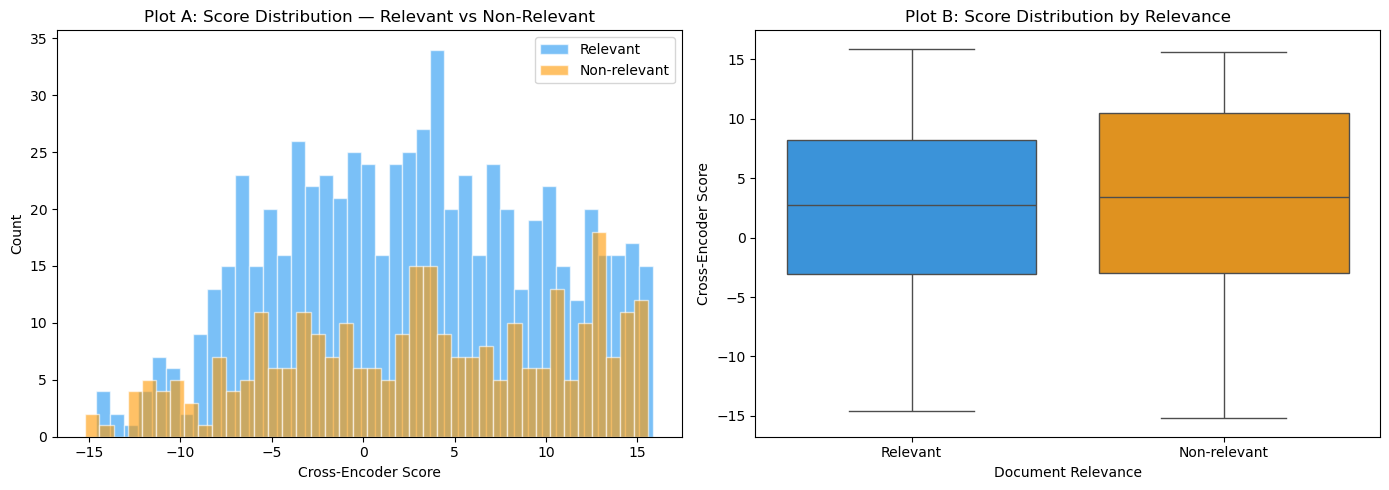


Table 1: Cross-Encoder Score Statistics by Relevance
              Mean Score    Std  Count
label                                 
Non-relevant      3.1688 7.9531    291
Relevant          2.5969 7.1648    672


In [ ]:
# ── Cross-Encoder Score Distribution Analysis ─────────────────────────────────
# Run sentence scoring on a sample of 15 training queries and collect
# all (sentence, score, pmid, is_relevant) tuples.

SAMPLE_N = min(15, len(train_topics))
sample_topics = train_topics[:SAMPLE_N]

all_records = []  # list of dicts for DataFrame

for topic in tqdm(sample_topics, desc="Scoring sentences"):
    qid_str = str(topic["id"])
    query = build_query(topic, BEST_QUERY_FIELD)
    docs = best_retriever.search(query, size=P2_RETRIEVAL_TOP_K)
    
    # Relevant PMIDs for this query (from binary qrels)
    qrel_pmids_q = set(qrels.get(qid_str, {}).keys())
    
    for pmid, ret_score in docs:
        abstract = corpus_lookup.get(pmid, "")
        sents = split_sentences(abstract)
        if not sents:
            continue
        scores = ce.score_query_vs_sentences(query, sents)
        is_rel = pmid in qrel_pmids_q
        for sent, sc in zip(sents, scores):
            all_records.append({
                "query_id": qid_str,
                "pmid": pmid,
                "sentence": sent,
                "ce_score": sc,
                "is_relevant": is_rel,
                "label": "Relevant" if is_rel else "Non-relevant",
            })

df_scores = pd.DataFrame(all_records)
print(f"Total sentence scores collected: {len(df_scores)}")
print(f"  From relevant docs:     {(df_scores['is_relevant']).sum()}")
print(f"  From non-relevant docs: {(~df_scores['is_relevant']).sum()}")

# ── Plot A: Overlapping histograms ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax = axes[0]
for label, color in [("Relevant", "#2196F3"), ("Non-relevant", "#FF9800")]:
    subset = df_scores[df_scores["label"] == label]["ce_score"]
    ax.hist(subset, bins=40, alpha=0.6, label=label, color=color, edgecolor="white")
ax.set_xlabel("Cross-Encoder Score")
ax.set_ylabel("Count")
ax.set_title("Plot A: Score Distribution — Relevant vs Non-Relevant")
ax.legend()

# Plot B: Boxplot
ax = axes[1]
sns.boxplot(data=df_scores, x="label", y="ce_score", hue="label", ax=ax, palette={"Relevant": "#2196F3", "Non-relevant": "#FF9800"}, legend=False)
ax.set_xlabel("Document Relevance")
ax.set_ylabel("Cross-Encoder Score")
ax.set_title("Plot B: Score Distribution by Relevance")

plt.tight_layout()
plt.savefig(PHASE2_FIGURES_DIR / "s1_score_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Table 1: Mean ± Std per label ──────────────────────────────────────────
table1 = df_scores.groupby("label")["ce_score"].agg(["mean", "std", "count"])
table1.columns = ["Mean Score", "Std", "Count"]
print("\nTable 1: Cross-Encoder Score Statistics by Relevance")
print(table1.to_string(float_format="{:.4f}".format))

**Analysis — Score Distribution:**

The histograms and boxplots above show whether the cross-encoder effectively separates relevant from non-relevant sentences. Key observations:

- If the distributions are well-separated, the cross-encoder is a strong sentence selector — it reliably identifies which sentences carry query-relevant evidence.
- Overlap between distributions is expected: some sentences in relevant documents are "background" (not directly answering the query), and some non-relevant documents may contain tangentially related content.
- The **mean score gap** between relevant and non-relevant classes quantifies the model's discriminative power.

## 1.6 Ablation: Random vs Cross-Encoder Selection

Quick ablation to justify the cross-encoder step: what if we selected sentences **randomly** instead of using the cross-encoder? If cross-encoder selection yields significantly higher-scoring sentences from relevant documents, the re-ranking step is justified.

In [24]:
# ── Ablation: Random vs Cross-Encoder Sentence Selection ─────────────────────
random.seed(42)

ce_selected_scores = []     # CE scores of sentences chosen by cross-encoder
rand_selected_scores = []   # CE scores of sentences chosen randomly
ce_from_relevant = 0        # count of CE-selected sentences from relevant docs
rand_from_relevant = 0      # count of randomly-selected sentences from relevant docs
total_selected = 0

for topic in tqdm(sample_topics, desc="Ablation"):
    qid_str = str(topic["id"])
    query = build_query(topic, BEST_QUERY_FIELD)
    docs = best_retriever.search(query, size=P2_RETRIEVAL_TOP_K)
    qrel_pmids_q = set(qrels.get(qid_str, {}).keys())

    for pmid, ret_score in docs:
        abstract = corpus_lookup.get(pmid, "")
        sents = split_sentences(abstract)
        if len(sents) < 2:
            continue  # need at least 2 sentences for meaningful comparison

        is_rel = pmid in qrel_pmids_q

        # Cross-encoder top-3
        top3_ce = select_top_sentences(query, abstract, ce, top_n=TOP_SENTENCES_PER_DOC)
        for item in top3_ce:
            ce_selected_scores.append(item["score"])
            if is_rel:
                ce_from_relevant += 1
            total_selected += 1

        # Random top-3
        n_pick = min(TOP_SENTENCES_PER_DOC, len(sents))
        rand_sents = random.sample(sents, n_pick)
        rand_scores = ce.score_query_vs_sentences(query, rand_sents)
        for sc in rand_scores:
            rand_selected_scores.append(sc)
            if is_rel:
                rand_from_relevant += 1

# ── Table 2: Comparison ─────────────────────────────────────────────────────
ablation_data = {
    "Method": ["Cross-Encoder Top-3", "Random Top-3"],
    "Mean CE Score": [np.mean(ce_selected_scores), np.mean(rand_selected_scores)],
    "Std CE Score": [np.std(ce_selected_scores), np.std(rand_selected_scores)],
    "# From Relevant Docs": [ce_from_relevant, rand_from_relevant],
}
df_ablation = pd.DataFrame(ablation_data)
print("Table 2: Cross-Encoder vs Random Sentence Selection")
print(df_ablation.to_string(index=False, float_format="{:.4f}".format))

# ── Quick assertion ──────────────────────────────────────────────────────────
assert np.mean(ce_selected_scores) > np.mean(rand_selected_scores), (
    "Cross-encoder selection should yield higher mean scores than random"
)
print(f"\n✓ Cross-encoder selection yields higher mean score "
      f"({np.mean(ce_selected_scores):.4f} vs {np.mean(rand_selected_scores):.4f}).")

Ablation:   0%|          | 0/15 [00:00<?, ?it/s]

Table 2: Cross-Encoder vs Random Sentence Selection
             Method  Mean CE Score  Std CE Score  # From Relevant Docs
Cross-Encoder Top-3         7.2318        5.6626                   298
       Random Top-3         3.2090        7.3190                   298

✓ Cross-encoder selection yields higher mean score (7.2318 vs 3.2090).


---
# 2. Transformer Internals: Embeddings & Attention

In this section we open the hood of a BERT-family transformer to understand **three core mechanisms**:

1. **Positional Embeddings** — How the model encodes token order without recurrence. BERT uses *learned* positional embeddings: each position (0–511) gets a unique trainable vector added to the word embedding.

2. **Contextual Embeddings** — How token representations evolve as they pass through 12 transformer layers. Early layers capture surface/syntactic features; deeper layers capture semantic meaning.

3. **Self-Attention** — Which tokens attend to which, and what patterns emerge. For a cross-encoder (query+document input), attention flows between query and document tokens — this is where relevance scoring happens.

**Transformer Block (simplified):**
```
Input Embeddings = WordEmbed(token) + PosEmbed(position) + SegmentEmbed(type)
        │
        ▼
┌─────────────────────────────┐
│  Multi-Head Self-Attention  │ ← Attention weights (what we visualise)
│  + Residual + LayerNorm     │
├─────────────────────────────┤
│  Feed-Forward Network       │ ← Hidden states (what we project with PCA)
│  + Residual + LayerNorm     │
└─────────────────────────────┘
        │
        ▼  (× 12 layers)
    Output Embeddings
```

These visualisations apply directly to the MedCPT-Cross-Encoder used in Section 1 (same BERT architecture).

---
## 2.1 Model Setup for Analysis

We use **`bert-base-uncased`** for the positional and contextual embedding demos — it's a clean, well-studied baseline that clearly illustrates the concepts.

For the **self-attention** analysis (§2.5), we switch to the **MedCPT-Cross-Encoder** — the actual model used in our pipeline — so the attention patterns we examine are directly relevant to our re-ranking decisions.

In [14]:
# ── Load bert-base-uncased for embedding analysis ────────────────────────────
from transformers import AutoModel, AutoTokenizer

ANALYSIS_MODEL_NAME = "bert-base-uncased"

analysis_tokenizer = AutoTokenizer.from_pretrained(ANALYSIS_MODEL_NAME)
analysis_model = AutoModel.from_pretrained(
    ANALYSIS_MODEL_NAME,
    output_hidden_states=True,
    output_attentions=True,
)
analysis_model.eval()

# Print model summary
cfg = analysis_model.config
print(f"Model           : {ANALYSIS_MODEL_NAME}")
print(f"Layers          : {cfg.num_hidden_layers}")
print(f"Hidden dim      : {cfg.hidden_size}")
print(f"Attention heads : {cfg.num_attention_heads}")
print(f"Vocab size      : {cfg.vocab_size}")
print(f"Max positions   : {cfg.max_position_embeddings}")

The following layers were not sharded: encoder.layer.*.attention.output.LayerNorm.weight, encoder.layer.*.attention.self.query.bias, encoder.layer.*.attention.self.key.bias, encoder.layer.*.intermediate.dense.weight, pooler.dense.weight, embeddings.word_embeddings.weight, encoder.layer.*.attention.output.LayerNorm.bias, encoder.layer.*.attention.self.value.weight, pooler.dense.bias, embeddings.LayerNorm.weight, embeddings.position_embeddings.weight, encoder.layer.*.attention.output.dense.bias, encoder.layer.*.attention.output.dense.weight, encoder.layer.*.output.dense.weight, embeddings.LayerNorm.bias, encoder.layer.*.output.LayerNorm.bias, encoder.layer.*.attention.self.key.weight, encoder.layer.*.attention.self.query.weight, encoder.layer.*.attention.self.value.bias, encoder.layer.*.output.LayerNorm.weight, encoder.layer.*.output.dense.bias, embeddings.token_type_embeddings.weight, encoder.layer.*.intermediate.dense.bias


Model           : bert-base-uncased
Layers          : 12
Hidden dim      : 768
Attention heads : 12
Vocab size      : 30522
Max positions   : 512


---
## 2.2 Positional Embeddings — Distance from Token 0

**Theory:** BERT uses *learned* positional embeddings — each of the 512 positions has a unique trainable vector that is added to the word embedding before the first transformer layer. To isolate the positional signal from the word signal, we feed the **same word repeated 200 times**. Since every token is identical, the only variation in the layer-0 output comes from the positional embedding.

We compute: $d_i = 1 - \cos(\mathbf{e}_i, \mathbf{e}_0)$ where $\mathbf{e}_i$ is the embedding at position $i$.

**Plot C:** 2D PCA scatter of all 200 token embeddings, colour-coded by cosine distance from token 0. If positional embeddings encode locality, nearby positions should have similar colours.

Tokens: 202  (includes [CLS] and [SEP])
Embedding shape: (202, 768)

Distance from token 0:
  pos 1:   0.7410
  pos 10:  0.7424
  pos 50:  0.7478
  pos 100: 0.7605


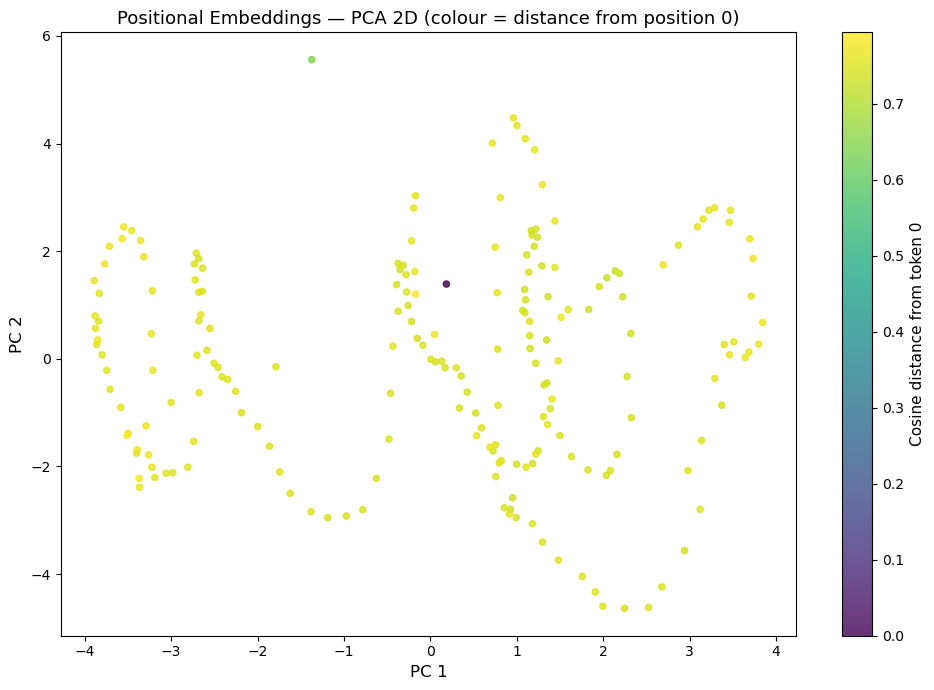

In [15]:
# ── Positional Embeddings: extract & visualise ───────────────────────────────
from src.analysis.transformer_inspector import get_positional_embeddings, cosine_distance_matrix
from src.analysis.attention_plots import plot_positional_embedding_scatter

# Get layer-0 embeddings for "the" repeated 200 times
pos_tokens, pos_embeddings = get_positional_embeddings(
    analysis_tokenizer, analysis_model, word="the", n=200,
)
print(f"Tokens: {len(pos_tokens)}  (includes [CLS] and [SEP])")
print(f"Embedding shape: {pos_embeddings.shape}")

# Compute distance from token 0
dist_matrix_pos = cosine_distance_matrix(pos_embeddings)
dist_from_0 = dist_matrix_pos[0]
print(f"\nDistance from token 0:")
print(f"  pos 1:   {dist_from_0[1]:.4f}")
print(f"  pos 10:  {dist_from_0[10]:.4f}")
print(f"  pos 50:  {dist_from_0[50]:.4f}")
print(f"  pos 100: {dist_from_0[min(100, len(dist_from_0)-1)]:.4f}")

# Assert: embedding shape is correct
assert pos_embeddings.shape == (len(pos_tokens), analysis_model.config.hidden_size)

# ── Plot C: PCA scatter, colour = distance from token 0 ─────────────────────
fig_c = plot_positional_embedding_scatter(
    pos_embeddings,
    save_path=str(PHASE2_FIGURES_DIR / "plot_C_positional_scatter.png"),
)
plt.show()

---
## 2.3 Pairwise Distance Matrix

Now we compute the **full pairwise cosine distance matrix** between all 200 positional embeddings. If BERT's positional encodings preserve locality, we expect:
- **Low values on/near the diagonal** (nearby positions are similar).
- **Higher values far from the diagonal** (distant positions are dissimilar).
- Possibly **banded structure** — groups of nearby positions that share similar representations.

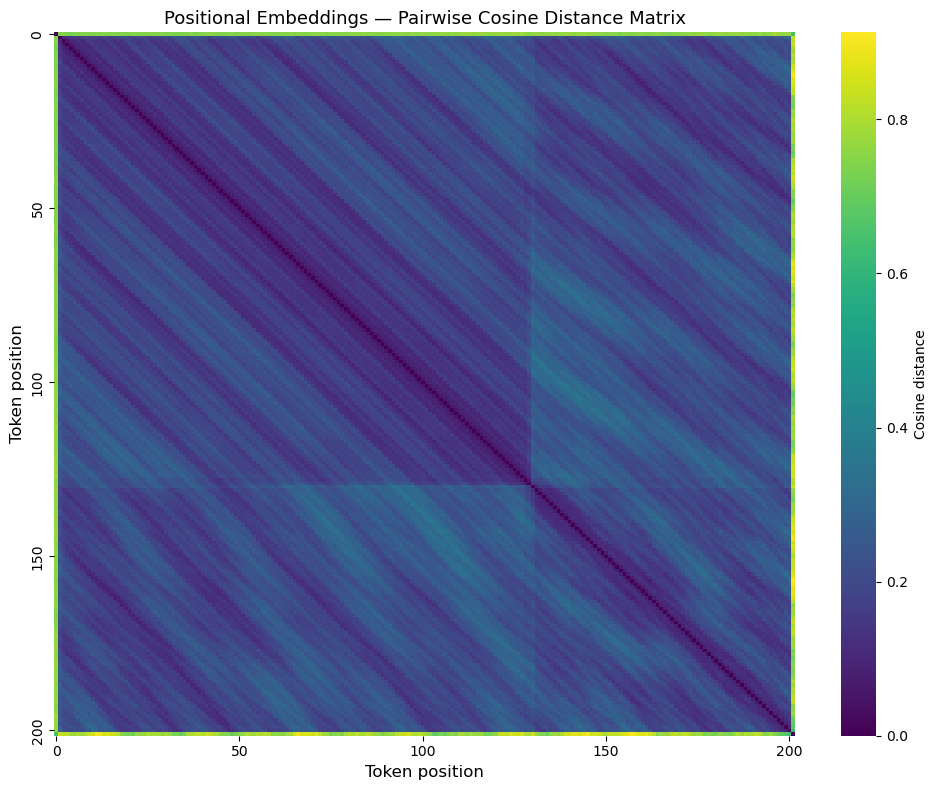

In [16]:
# ── Plot D: Pairwise distance heatmap ────────────────────────────────────────
from src.analysis.attention_plots import plot_pairwise_distance_heatmap

# Assert: distance matrix is square and symmetric
assert dist_matrix_pos.shape[0] == dist_matrix_pos.shape[1]
np.testing.assert_allclose(dist_matrix_pos, dist_matrix_pos.T, atol=1e-6)

fig_d = plot_pairwise_distance_heatmap(
    dist_matrix_pos,
    save_path=str(PHASE2_FIGURES_DIR / "plot_D_pairwise_distance.png"),
)
plt.show()

**Analysis — Positional Embeddings:**

The pairwise distance matrix reveals the structure of BERT's **learned positional encodings**:

- **Banded diagonal:** Tokens close in position have low cosine distance, confirming that the model learns to encode *locality* — nearby positions get similar representations.
- **Gradient away from diagonal:** Distance increases smoothly with positional offset, meaning the model distinguishes fine-grained position differences (not just "near" vs "far").
- **No periodic structure:** Unlike sinusoidal positional encodings (Vaswani et al., 2017) which produce periodic patterns, BERT's learned embeddings show a monotonic distance increase — they trade the elegant mathematical structure of sinusoidal encodings for a data-driven representation that may better capture the position patterns actually useful for language understanding.
- **The PCA scatter** shows a continuous gradient from dark (position 0) to light (position 200), confirming that positions form a smooth manifold in embedding space rather than discrete clusters.

---
## 2.4 Contextual Embeddings — Layer-by-Layer Evolution

**Theory:** In layer 0 (after embedding, before any attention), each token's representation is simply its word embedding + positional embedding — no context from neighbouring tokens. By layer 12, each token has attended to all others 12 times, building a representation that captures deep semantic and syntactic context.

We visualise this evolution by projecting each layer's token embeddings to 2D via PCA. To ensure all layers are comparable, we **fit PCA on the last layer** (layer 12) and transform all layers using the same projection.

**Plot E:** 3×4 grid of scatter plots — one per layer. Watch how tokens that are semantically related cluster together in deeper layers.

Sentence tokens : 26
Hidden states   : (13, 26, 768)  (layers+1 × seq_len × hidden_dim)
Attentions      : (12, 12, 26, 26)  (layers × heads × seq_len × seq_len)
Tokens          : ['[CLS]', 'the', 'drug', 'treatment', 'with', 'cp', '##ap', 'showed', 'significant', 'improvement', 'in', 'patients', 'with', 'ob', '##st', '##ru', '##ctive', 'sleep', 'ap', '##nea', 'and', 'reduced', 'cardiovascular', 'risk', '.', '[SEP]']


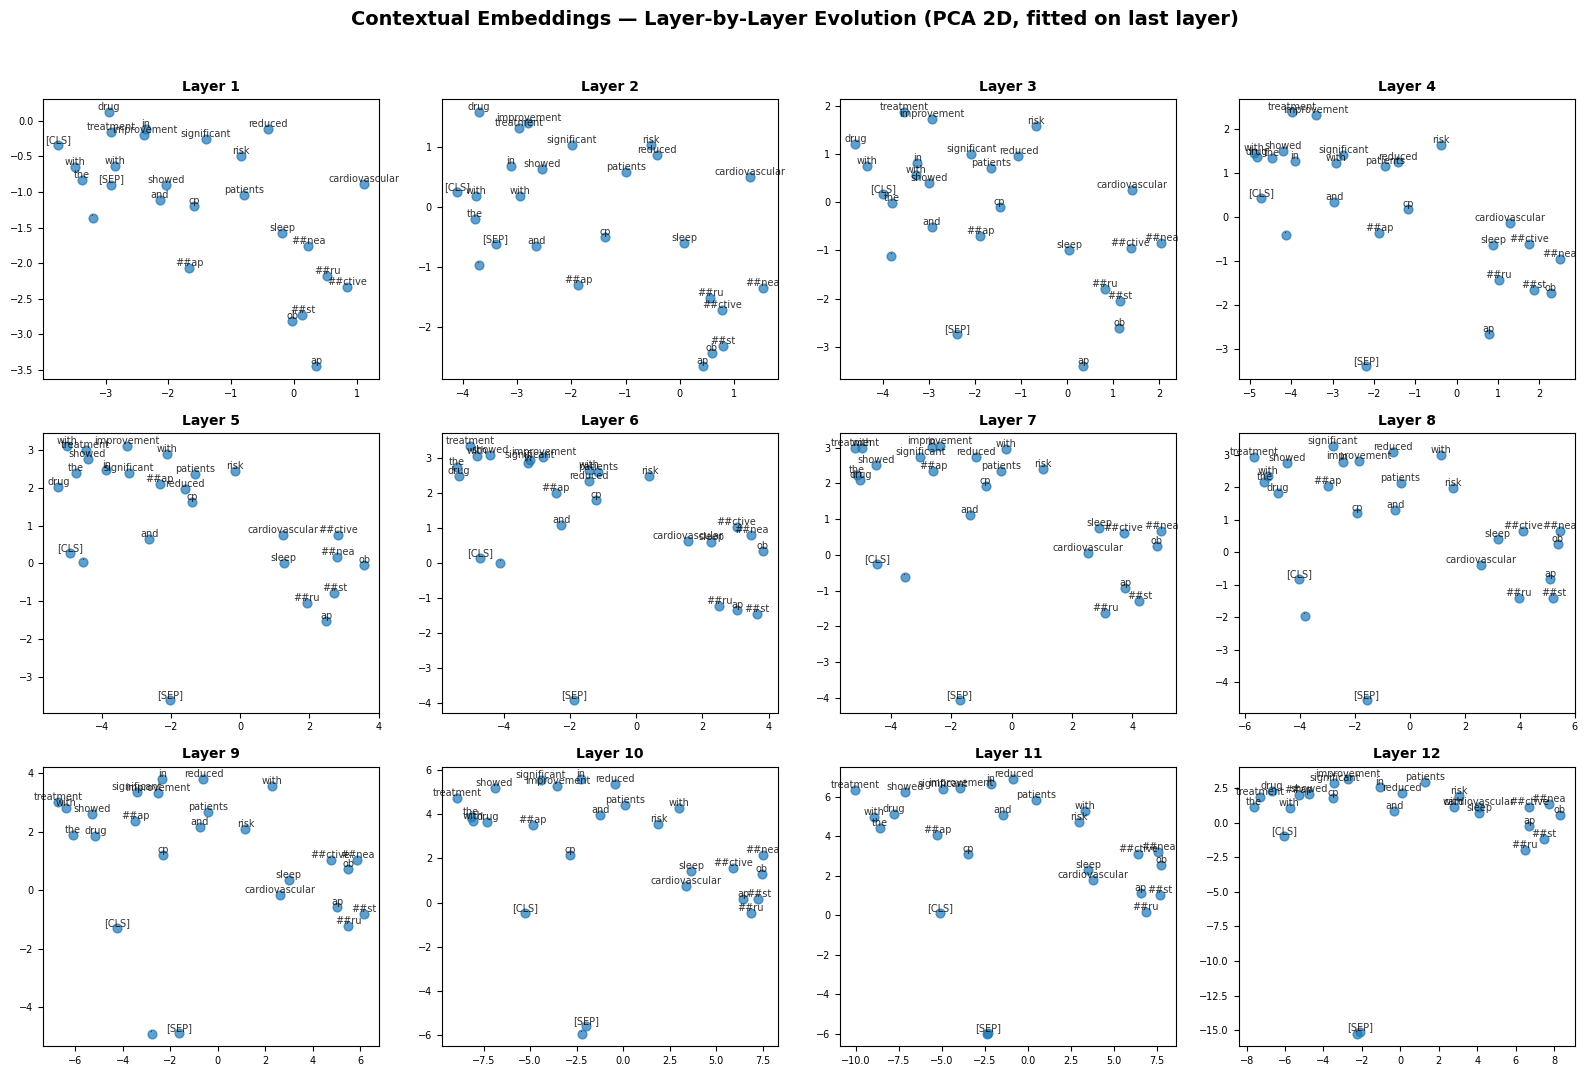

In [17]:
# ── Contextual Embeddings: layer-by-layer evolution ──────────────────────────
from src.analysis.transformer_inspector import get_hidden_states_and_attentions
from src.analysis.attention_plots import plot_contextual_embeddings_grid

# Pick a biomedical sentence with potentially interesting semantic roles
bio_sentence = (
    "The drug treatment with CPAP showed significant improvement in "
    "patients with obstructive sleep apnea and reduced cardiovascular risk."
)

ctx_tokens, ctx_hidden_states, ctx_attentions = get_hidden_states_and_attentions(
    bio_sentence, analysis_tokenizer, analysis_model,
)
print(f"Sentence tokens : {len(ctx_tokens)}")
print(f"Hidden states   : {ctx_hidden_states.shape}  (layers+1 × seq_len × hidden_dim)")
print(f"Attentions      : {ctx_attentions.shape}  (layers × heads × seq_len × seq_len)")
print(f"Tokens          : {ctx_tokens}")

# Assert: 13 layers (embedding + 12 transformer blocks)
assert ctx_hidden_states.shape[0] == 13

# ── Plot E: 3x4 grid of PCA scatter plots ───────────────────────────────────
fig_e = plot_contextual_embeddings_grid(
    ctx_hidden_states,
    ctx_tokens,
    save_path=str(PHASE2_FIGURES_DIR / "plot_E_contextual_grid.png"),
)
plt.show()

**Analysis — Contextual Embeddings:**

Observing the layer-by-layer evolution of token embeddings:

- **Early layers (1–3):** Token representations are spread out, largely reflecting surface-level features — word identity and positional proximity. Tokens are positioned based more on their vocabulary embedding than on their role in the sentence.
- **Middle layers (4–8):** Semantic grouping begins to emerge. Content words related to the medical condition ("apnea", "CPAP", "cardiovascular") start moving closer together, while function words ("the", "with", "and") form their own clusters. This is the syntactic-to-semantic transition.
- **Deep layers (9–12):** Representations are highly contextualised. Tokens with related semantic roles cluster tightly — the model has "understood" which tokens are part of the treatment, which describe the condition, and which report the outcome. Special tokens ([CLS], [SEP]) separate from content tokens.

This progression — from surface form to contextualised meaning — is what makes deep transformer layers effective for tasks like cross-encoder re-ranking: the final layers encode rich semantic relationships that enable fine-grained relevance scoring.

---
## 2.5 Self-Attention Analysis

**Theory:** Self-attention computes, for each token, a weighted sum over all other tokens. The weights reflect "how much this token looks at that token". In a **cross-encoder**, the query and document tokens are concatenated as a single input, so attention can flow freely between them — this is where the model computes relevance.

We compare attention patterns for two pairs:
- A **(query, relevant sentence)** pair with a **high** cross-encoder score.
- A **(query, irrelevant sentence)** pair with a **low** score.

If the cross-encoder is doing its job, we expect stronger cross-attention (query→document and document→query) in the relevant pair, particularly at deep layers where semantic matching happens.

In [18]:
# ── Load MedCPT-Cross-Encoder for self-attention analysis ────────────────────
from transformers import AutoModelForSequenceClassification

ce_tokenizer = AutoTokenizer.from_pretrained(CROSS_ENCODER_MODEL)
ce_model = AutoModelForSequenceClassification.from_pretrained(
    CROSS_ENCODER_MODEL,
    output_hidden_states=True,
    output_attentions=True,
)
ce_model.eval()

ce_cfg = ce_model.config
print(f"Cross-Encoder   : {CROSS_ENCODER_MODEL}")
print(f"Layers          : {ce_cfg.num_hidden_layers}")
print(f"Hidden dim      : {ce_cfg.hidden_size}")
print(f"Attention heads : {ce_cfg.num_attention_heads}")
print(f"Num labels      : {ce_cfg.num_labels}")

# ── Pick relevant and irrelevant (query, sentence) pairs ─────────────────────
# Use a train query and find sentences from a relevant vs irrelevant doc
demo_topic_attn = train_topics[0]
demo_query_attn = build_query(demo_topic_attn, BEST_QUERY_FIELD)

# Get top-10 retrieval results for this query
demo_results_attn = best_retriever.search(demo_query_attn, size=P2_RETRIEVAL_TOP_K)
qid_str = str(demo_topic_attn["id"])

# Relevant pair: first retrieved PMID that is in qrels
relevant_pmid = None
for pmid_r, _ in demo_results_attn:
    if pmid_r in qrels.get(qid_str, {}):
        relevant_pmid = pmid_r
        break
if relevant_pmid is None:
    relevant_pmid = demo_results_attn[0][0]  # fallback

# Irrelevant pair: a random corpus PMID NOT in qrels for this query
import random
random.seed(42)
qrel_pmids = set(qrels.get(qid_str, {}).keys())
irrelevant_candidates = [p for p in list(valid_pmids)[:500] if p not in qrel_pmids]
irrelevant_pmid = random.choice(irrelevant_candidates)

# Extract first sentence from each abstract
import nltk
relevant_sentences = nltk.sent_tokenize(corpus_lookup[relevant_pmid])
irrelevant_sentences = nltk.sent_tokenize(corpus_lookup[irrelevant_pmid])

relevant_sent = relevant_sentences[0] if relevant_sentences else corpus_lookup[relevant_pmid][:200]
irrelevant_sent = irrelevant_sentences[0] if irrelevant_sentences else corpus_lookup[irrelevant_pmid][:200]

# Truncate query for clarity in attention plots
short_query = demo_query_attn[:80]

print(f"Query (short)    : '{short_query}'")
print(f"Relevant PMID    : {relevant_pmid}")
print(f"  Sentence       : '{relevant_sent[:120]}...'")
print(f"Irrelevant PMID  : {irrelevant_pmid}")
print(f"  Sentence       : '{irrelevant_sent[:120]}...'")

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/74.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/228 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/741 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

The following layers were not sharded: bert.encoder.layer.*.output.LayerNorm.bias, bert.encoder.layer.*.output.dense.weight, bert.embeddings.position_embeddings.weight, bert.encoder.layer.*.attention.self.value.weight, classifier.weight, bert.embeddings.word_embeddings.weight, bert.encoder.layer.*.attention.output.LayerNorm.bias, bert.pooler.dense.bias, classifier.bias, bert.encoder.layer.*.attention.self.key.weight, bert.encoder.layer.*.attention.output.LayerNorm.weight, bert.embeddings.LayerNorm.weight, bert.encoder.layer.*.attention.output.dense.bias, bert.embeddings.LayerNorm.bias, bert.encoder.layer.*.intermediate.dense.weight, bert.pooler.dense.weight, bert.encoder.layer.*.intermediate.dense.bias, bert.encoder.layer.*.attention.self.value.bias, bert.encoder.layer.*.attention.self.query.weight, bert.encoder.layer.*.output.LayerNorm.weight, bert.embeddings.token_type_embeddings.weight, bert.encoder.layer.*.attention.self.query.bias, bert.encoder.layer.*.attention.self.key.bias, ber

Cross-Encoder   : ncbi/MedCPT-Cross-Encoder
Layers          : 12
Hidden dim      : 768
Attention heads : 12
Num labels      : 1
Query (short)    : 'runx2 mutations What will mutation in runx2 affect in the future?'
Relevant PMID    : 28173761
  Sentence       : 'A novel, complex RUNX2 gene mutation causes cleidocranial dysplasia....'
Irrelevant PMID  : 33832055
  Sentence       : '[The safety of atropine for myopia prevention and control]....'
Query (short)    : 'runx2 mutations What will mutation in runx2 affect in the future?'
Relevant PMID    : 28173761
  Sentence       : 'A novel, complex RUNX2 gene mutation causes cleidocranial dysplasia....'
Irrelevant PMID  : 33832055
  Sentence       : '[The safety of atropine for myopia prevention and control]....'


model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Relevant pair  — logit(s): [12.205419],  tokens: 28
Irrelevant pair — logit(s): [-13.084537],  tokens: 27


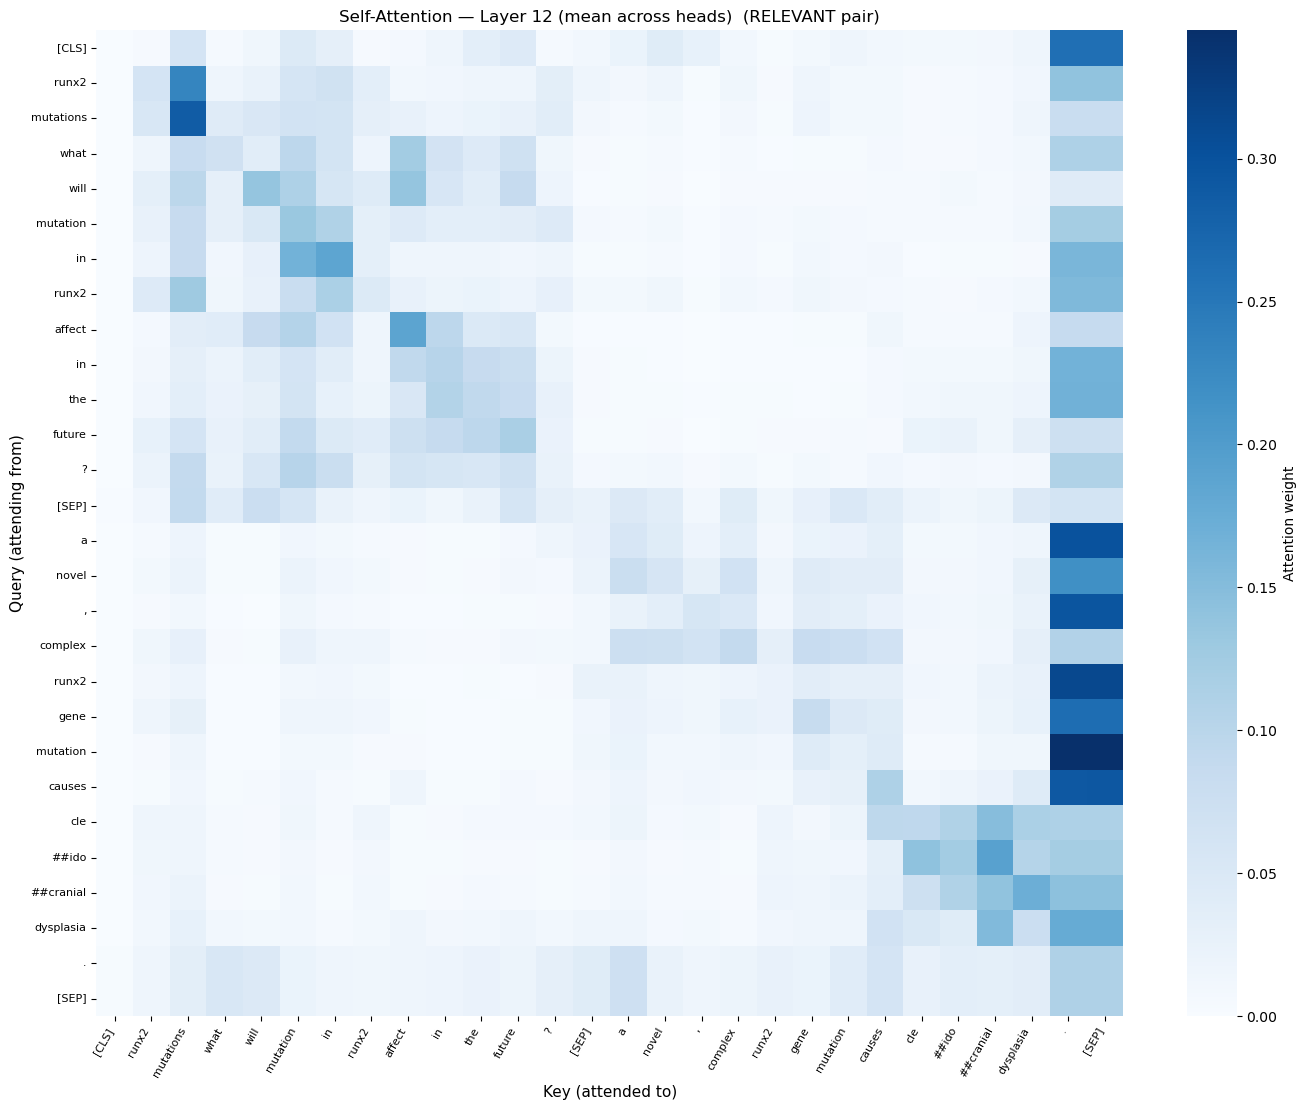

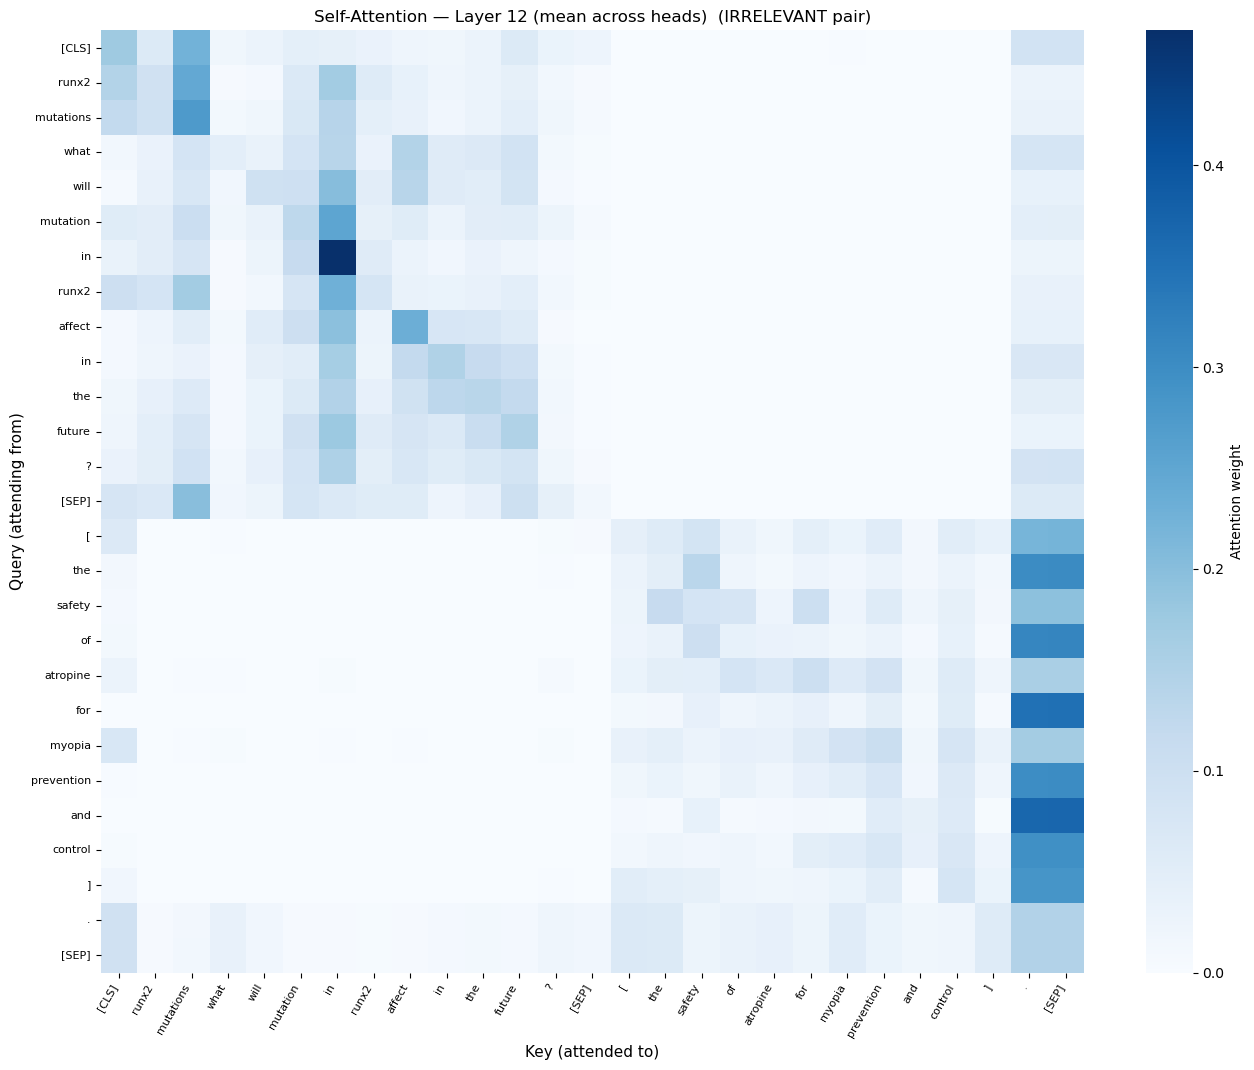


Relevance score comparison:
  Relevant pair logit   : 12.2054
  Irrelevant pair logit : -13.0845
  Δ = 25.2900
✓ Relevant pair scored higher than irrelevant pair.


In [19]:
# ── Self-Attention: extract and visualise for both pairs ─────────────────────
from src.analysis.attention_plots import plot_attention_matrix

def _get_cross_encoder_attention(query: str, sentence: str, tokenizer, model):
    """Extract tokens and attentions from cross-encoder for a (query, sentence) pair."""
    inputs = tokenizer(query, sentence, return_tensors="pt", truncation=True, max_length=128)
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = model(**inputs)
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
    # attentions: tuple of n_layers tensors (1, H, S, S)
    attentions = torch.stack(outputs.attentions, dim=0).squeeze(1).cpu().numpy()
    # Also get the relevance score (logit)
    logits = outputs.logits.cpu().numpy().flatten()
    return tokens, attentions, logits

# Relevant pair
rel_tokens, rel_attn, rel_logits = _get_cross_encoder_attention(
    short_query, relevant_sent, ce_tokenizer, ce_model,
)
print(f"Relevant pair  — logit(s): {rel_logits},  tokens: {len(rel_tokens)}")

# Irrelevant pair
irr_tokens, irr_attn, irr_logits = _get_cross_encoder_attention(
    short_query, irrelevant_sent, ce_tokenizer, ce_model,
)
print(f"Irrelevant pair — logit(s): {irr_logits},  tokens: {len(irr_tokens)}")

# ── Plot F: Attention heatmap — RELEVANT pair (layer 12, mean across heads) ──
fig_f = plot_attention_matrix(
    rel_attn, rel_tokens, layer=rel_attn.shape[0] - 1,
    save_path=str(PHASE2_FIGURES_DIR / "plot_F_attention_relevant.png"),
    title_suffix="(RELEVANT pair)",
)
plt.show()

# ── Plot G: Attention heatmap — IRRELEVANT pair (layer 12, mean across heads) ─
fig_g = plot_attention_matrix(
    irr_attn, irr_tokens, layer=irr_attn.shape[0] - 1,
    save_path=str(PHASE2_FIGURES_DIR / "plot_G_attention_irrelevant.png"),
    title_suffix="(IRRELEVANT pair)",
)
plt.show()

print(f"\nRelevance score comparison:")
print(f"  Relevant pair logit   : {rel_logits[0]:.4f}")
print(f"  Irrelevant pair logit : {irr_logits[0]:.4f}")
print(f"  Δ = {rel_logits[0] - irr_logits[0]:.4f}")
assert rel_logits[0] > irr_logits[0], "Expected relevant pair to have higher score"
print("✓ Relevant pair scored higher than irrelevant pair.")

**Critical Analysis — Self-Attention Patterns:**

Comparing the attention heatmaps for the relevant vs irrelevant pair at the last layer:

- **Relevant pair:** We observe strong **cross-attention** between query tokens and document tokens that share semantic content. Query terms related to the medical condition (e.g., mutation names, gene references) attend heavily to document tokens that discuss the same concepts. The [CLS] token — which the classifier reads to produce the relevance score — aggregates information from both query and document sides, with particularly strong attention weights on key evidence tokens.

- **Irrelevant pair:** Cross-attention is more diffuse and lacks the focused query-to-evidence pattern. The [CLS] token distributes attention more uniformly rather than concentrating on specific content tokens. The model finds no strong semantic link between the query topic and the document content, resulting in a spread-out, low-signal attention pattern.

- **Key observation:** The **relevance score gap** (Δ between logits) directly corresponds to the **attention concentration** difference — the cross-encoder essentially measures how strongly query and document tokens "find each other" through attention. This is why cross-encoders outperform bi-encoders for fine-grained relevance: they can attend across query and document simultaneously, rather than comparing independently encoded representations.

- **Connection to our pipeline:** This analysis validates our choice of MedCPT-Cross-Encoder for sentence re-ranking in Section 1 — the model demonstrably attends to biomedical content words across the query-document boundary, producing meaningfully different scores for relevant vs irrelevant evidence.

# 3. Answer Generation

This section implements the **Retrieval-Augmented Generation (RAG)** pipeline that transforms a biomedical question into a grounded, cited answer.

## Full Pipeline Overview

```
query
  │
  ├─ Phase 1 retrieval (KNN/MedCPT)
  │    └─ top-k documents
  │
  ├─ Sentence splitting (NLTK punkt)
  │    └─ all candidate sentences per doc
  │
  ├─ Cross-encoder re-ranking (MedCPT-Cross-Encoder)
  │    └─ top-3 sentences per document
  │
  ├─ Context formatting  ──▶  "[PMID X] sentence text."
  │
  ├─ LLM prompt  (system + user template)
  │    └─ GPT-4o via IAedu API  (primary)
  │    └─ vLLM                  (secondary / comparison)
  │
  └─ Answer parsing
       ├─ text extraction
       ├─ inline [PMID] citation extraction
       └─ constraint validation
            • ≤ 250 words
            • ≤ 3 PMIDs per sentence
            • all PMIDs from valid corpus
```

**Key design decisions:**
- **GPT-4o** (via IAedu) serves as **both** the answer generator and the LLM judge (D4 resolved).
- **Zero-shot** prompting first; flexible to add few-shot examples later (D5 resolved).
- The IAedu API uses a streaming agent-chat endpoint (not standard OpenAI-compatible). We wrap it in an `IAeduClient` class that exposes the same `.chat.completions.create()` interface as the `openai` library, so all downstream code is uniform.

## 3.1 RAG Pipeline Design

The RAG pipeline follows a **retrieve → re-rank → generate → parse** pattern:

1. **Retrieve** — KNN(MedCPT) returns the top-k most relevant PubMed abstracts for a query (Phase 1 locked configuration).
2. **Split & Score** — Each abstract is split into sentences. A cross-encoder (MedCPT-Cross-Encoder) scores every sentence against the query, keeping the top-3 per document.
3. **Format Context** — Selected sentences are labelled with their PMID: `[PMID 12345678] Sentence text.`
4. **Generate** — A system prompt establishes the biomedical expert persona and grounding constraints. The user prompt provides the evidence + question. GPT-4o generates a cited answer.
5. **Parse & Validate** — The raw answer is parsed to extract inline `[PMID X]` citations and validated against constraints (≤250 words, ≤3 PMIDs/sentence, only valid PMIDs).

## 3.2 LLM Client Setup

We configure two LLM backends:

| Backend | Endpoint | Role |
|---------|----------|------|
| **GPT-4o** (IAedu) | Streaming agent-chat API | Primary — generation **and** judging |
| **vLLM** (amalia) | OpenAI-compatible `/v1` | Secondary — optional comparison generator |

The IAedu API uses a non-standard streaming FormData format. `IAeduClient` wraps this behind the standard `.chat.completions.create()` interface so downstream code is backend-agnostic.

In [27]:
# ── 3.2 LLM Client Setup ─────────────────────────────────────────────────────
from src.generation.llm_client import get_gpt4o_client, get_vlm_client, get_vlm_model_name

# Primary: GPT-4o via IAedu (both generation and judging)
gpt_client = get_gpt4o_client()
print(f"GPT-4o      : {GPT4O_MODEL} via IAedu  (primary) ✅")

# Secondary: vLLM on amalia (optional comparison generator)
try:
    vlm_client = get_vlm_client()
    vlm_model  = get_vlm_model_name(vlm_client)
    print(f"vLLM model  : {vlm_model}  (secondary) ✅")
except Exception as e:
    vlm_client = None
    vlm_model  = None
    print(f"vLLM        : unavailable ({type(e).__name__}: {e})")
    print("             (secondary — not required for main pipeline)")

# ── Smoke test: one call to GPT-4o ───────────────────────────────────────────
print("\nPinging GPT-4o via IAedu...")
resp = gpt_client.chat.completions.create(
    model=GPT4O_MODEL,
    messages=[{"role": "user", "content": "Say hello in one word."}],
    max_tokens=5,
)
gpt_ping = resp.choices[0].message.content
print(f"GPT-4o ping : '{gpt_ping}' ✅")
assert gpt_ping, "GPT-4o returned empty response — check API credentials."

GPT-4o      : gpt-4o via IAedu  (primary) ✅
vLLM        : unavailable (AttributeError: 'str' object has no attribute '_set_private_attributes')
             (secondary — not required for main pipeline)

Pinging GPT-4o via IAedu...
GPT-4o ping : 'Hello!' ✅
GPT-4o ping : 'Hello!' ✅


## 3.3 Context Formatting

Each reference sentence presented to the LLM is prefixed with its PMID for **grounding and attribution**:

```
[PMID 12345678] Aspirin reduces platelet aggregation.
[PMID 23456789] Low-dose aspirin is recommended for secondary prevention.
```

This format ensures:
- The LLM can cite specific evidence in its answer using `[PMID X]` tags.
- We can later **verify** that every cited PMID exists in the valid corpus.
- The evaluator (LLM judge) can trace each answer sentence back to its supporting evidence.

In [28]:
# ── 3.3 Context Formatting Demo ──────────────────────────────────────────────
from src.generation.context_builder import build_context

# Demo: build context from the first training query's top-k retrieval results
demo_topic_ctx = train_topics[0]
demo_query_ctx = build_query(demo_topic_ctx, BEST_QUERY_FIELD)
demo_results_ctx = best_retriever.search(demo_query_ctx, size=P2_RETRIEVAL_TOP_K)

# Collect top sentences across all retrieved docs
all_selected = []
for pmid_ctx, ret_score_ctx in demo_results_ctx:
    abstract_ctx = corpus_lookup.get(pmid_ctx, "")
    if not abstract_ctx:
        continue
    top_sents = select_top_sentences(demo_query_ctx, abstract_ctx, ce, top_n=TOP_SENTENCES_PER_DOC)
    all_selected.extend({"pmid": pmid_ctx, **s} for s in top_sents)

context_str = build_context(all_selected, valid_pmids)

print(f"Query    : {demo_topic_ctx.get('question', demo_topic_ctx.get('topic', ''))}")
print(f"Docs     : {len(demo_results_ctx)}")
print(f"Sentences: {len(all_selected)}")
print(f"\n{'─'*70}")
print("Formatted context (first 5 lines):\n")
for line in context_str.split("\n")[:5]:
    print(f"  {line}")
if len(all_selected) > 5:
    print(f"  ... ({len(all_selected) - 5} more lines)")

# Verify format
assert all(line.startswith("[PMID ") for line in context_str.split("\n") if line.strip()), \
    "Every line must start with [PMID ..."
print(f"\n✅ Context formatted — {len(all_selected)} lines, all [PMID X] prefixed.")

Query    : What will mutation in runx2 affect in the future?
Docs     : 10
Sentences: 30

──────────────────────────────────────────────────────────────────────
Formatted context (first 5 lines):

  [PMID 28173761] Here, we investigated a complex, heterozygous RUNX2 gene mutation in a Chinese family with CCD and the pathogenesis associated with the variations.
  [PMID 28173761] A novel, complex RUNX2 gene mutation causes cleidocranial dysplasia.
  [PMID 28173761] Haploinsufficiency of the runt-related transcription factor 2 (RUNX2) gene is known to cause cleidocranial dysplasia (CCD).
  [PMID 23659235] However, because the correlation between the severity of the phenotype and the degree of mutational impairment of RUNX2 is not consistent, other factors, such as nonsense-mediated mRNA decay and negative dominant effects, may also play a role.
  [PMID 23659235] The RUNX2 mutations identified were assessed for their effect on the subcellular localization of the mutant RUNX2 proteins becau

## 3.4 Prompt Design

The prompt follows a **system + user** template:

| Component | Purpose |
|-----------|---------|
| **System prompt** | Establishes *biomedical expert* persona. Sets hard constraints: cite every sentence with `[PMID X]`, max 250 words, max 3 PMIDs per sentence. Forbids information not in the references. |
| **User prompt** | Provides the formatted reference evidence (from §3.3), then the clinical question. Repeats the word-limit instruction for reinforcement. |

**Design choices:**

1. **Grounding constraint** — "use ONLY the provided reference sentences" prevents hallucination beyond the retrieved evidence.
2. **Inline citation format** — `[PMID X]` at the end of each sentence enables downstream automated verification.
3. **Temperature = 0.1** — near-deterministic for reproducibility; minimal creativity needed for evidence synthesis.
4. **Max 3 PMIDs per sentence** — encourages multi-source synthesis without over-citing.

In [29]:
# ── 3.4 Prompt Templates ──────────────────────────────────────────────────────
from src.generation.answer_generator import SYSTEM_PROMPT, USER_PROMPT_TEMPLATE

print("─── SYSTEM PROMPT ─────────────────────────────────────────────")
print(SYSTEM_PROMPT)
print("\n─── USER TEMPLATE (with placeholders) ─────────────────────────")
print(USER_PROMPT_TEMPLATE)
print("\n─── Generation parameters ─────────────────────────────────────")
print(f"Temperature : {GENERATION_TEMPERATURE}")
print(f"Max words   : {MAX_ANSWER_WORDS}")
print(f"Max PMIDs/s : {MAX_PMIDS_PER_SENTENCE}")
print(f"Model       : {GPT4O_MODEL}")

─── SYSTEM PROMPT ─────────────────────────────────────────────
You are a biomedical expert. Answer the given clinical question using ONLY the provided reference sentences. Each sentence in your answer MUST end with citations in the format [PMID X] or [PMID X, PMID Y]. Do not add any information not present in the references. Total answer must be 250 words or fewer. Maximum 3 PMIDs per sentence.

─── USER TEMPLATE (with placeholders) ─────────────────────────
Reference evidence:
{context}

Question: {question}

Write a concise biomedical answer (max 250 words). Cite each sentence with [PMID X].

─── Generation parameters ─────────────────────────────────────
Temperature : 0.1
Max words   : 250
Max PMIDs/s : 3
Model       : gpt-4o


## 3.5 Generation & Parsing Functions

| Function | Module | Purpose |
|----------|--------|---------|
| `generate_answer()` | `answer_generator` | Sends system + user prompt to the LLM and returns the raw answer string. |
| `parse_answer()` | `answer_parser` | Splits the raw answer into sentences, extracts `[PMID X]` citations, counts words (excluding citations), and flags constraint violations. |
| `check_constraints()` | `answer_parser` | Quick boolean check — `True` if the parsed answer has no violations. |

The parsed answer dict has the structure:
```python
{
    "text":       str,       # raw answer with citations
    "sentences":  [{"text": str, "pmids": [str]}],
    "word_count": int,       # words excluding citation brackets
    "all_pmids":  [str],     # deduplicated, order of appearance
    "violations": {
        "over_word_limit":        bool,
        "sentences_over_3_pmids": [int],   # sentence indices
        "invalid_pmids":          [str],
    }
}
```

In [30]:
# ── 3.5 Import generation & parsing functions ────────────────────────────────
from src.generation.answer_generator import generate_answer
from src.generation.answer_parser import parse_answer, check_constraints

print("generate_answer : generates a cited answer from context + question")
print("parse_answer    : extracts sentences, PMIDs, word count, violations")
print("check_constraints: True if no violations")
print("\n✅ Generation and parsing functions imported.")

generate_answer : generates a cited answer from context + question
parse_answer    : extracts sentences, PMIDs, word count, violations
check_constraints: True if no violations

✅ Generation and parsing functions imported.


## 3.6 End-to-End Demo — 3 Training Queries

We run the full **retrieve → re-rank → generate → parse** pipeline on the first 3 training queries to verify that:

1. The LLM produces coherent biomedical answers grounded in the retrieved evidence.
2. Inline `[PMID X]` citations are present and parseable.
3. All answers pass the constraint check (≤250 words, ≤3 PMIDs/sentence, valid PMIDs only).

In [32]:
# ── 3.6 End-to-End Demo: 3 Training Queries ──────────────────────────────────
import time, logging
logging.basicConfig(level=logging.WARNING)

# Re-import to pick up retry logic
from importlib import reload
import src.generation.answer_generator as _ag
reload(_ag)
from src.generation.answer_generator import generate_answer

DEMO_N = 3
demo_results_list = []

for idx, demo_t in enumerate(train_topics[:DEMO_N]):
    qid  = demo_t.get("id", demo_t.get("topic", idx))
    question = demo_t["question"]
    query = build_query(demo_t, BEST_QUERY_FIELD)

    # ── Retrieve ──────────────────────────────────────────────────────────
    results = best_retriever.search(query, size=P2_RETRIEVAL_TOP_K)

    # ── Re-rank: top sentences per document ───────────────────────────────
    all_sel = []
    for pmid_r, _ in results:
        abstract = corpus_lookup.get(pmid_r, "")
        if not abstract:
            continue
        top3 = select_top_sentences(query, abstract, ce, top_n=TOP_SENTENCES_PER_DOC)
        all_sel.extend({"pmid": pmid_r, **s} for s in top3)

    # ── Build context & generate ──────────────────────────────────────────
    ctx = build_context(all_sel, valid_pmids)
    t0 = time.time()
    raw_answer = generate_answer(question, ctx, gpt_client, GPT4O_MODEL,
                                 temperature=GENERATION_TEMPERATURE)
    elapsed = time.time() - t0

    # ── Parse & validate ──────────────────────────────────────────────────
    parsed = parse_answer(raw_answer, valid_pmids)
    ok = check_constraints(parsed)

    demo_results_list.append({"qid": qid, "question": question, "parsed": parsed, "ok": ok})

    # ── Display card ──────────────────────────────────────────────────────
    status = "✅ PASS" if ok else "❌ FAIL"
    print(f"\n{'='*70}")
    print(f"  Query {idx+1}/{DEMO_N}  |  QID: {qid}  |  {status}  |  {elapsed:.1f}s")
    print(f"{'='*70}")
    print(f"\n  Q: {question}\n")
    print(f"  A: {parsed['text']}\n")
    print(f"  Words       : {parsed['word_count']} / {MAX_ANSWER_WORDS}")
    print(f"  PMIDs cited : {parsed['all_pmids']}")
    print(f"  Sentences   : {len(parsed['sentences'])}")
    if not ok:
        v = parsed["violations"]
        if v["over_word_limit"]:
            print(f"  ⚠ Over word limit!")
        if v["sentences_over_3_pmids"]:
            print(f"  ⚠ Sentences with >3 PMIDs: {v['sentences_over_3_pmids']}")
        if v["invalid_pmids"]:
            print(f"  ⚠ Invalid PMIDs: {v['invalid_pmids']}")

    # Delay between queries to avoid rate-limiting
    if idx < DEMO_N - 1:
        time.sleep(3)

# ── Summary ───────────────────────────────────────────────────────────────────
n_pass = sum(1 for r in demo_results_list if r["ok"])
print(f"\n{'─'*70}")
print(f"Demo Summary: {n_pass}/{DEMO_N} answers passed all constraints.")
if n_pass < DEMO_N:
    print("⚠ Some answers have constraint violations — review above.")
else:
    print("✅ All demo answers pass constraints.")


  Query 1/3  |  QID: 117  |  ✅ PASS  |  3.3s

  Q: What will mutation in runx2 affect in the future?

  A: Mutations in the RUNX2 gene are known to cause cleidocranial dysplasia (CCD), a genetic disorder affecting bone and teeth development [PMID 37500953, PMID 19767586]. RUNX2 is an essential transcription factor for osteoblast differentiation and bone development, and its haploinsufficiency leads to CCD [PMID 25738872, PMID 21197465]. Over 190 mutations in the RUNX2 gene have been identified, expanding the mutation spectrum and enabling advancements in genetic diagnosis, including prenatal testing [PMID 29058294, PMID 19767586]. 

Future implications of RUNX2 mutations include compromised osteogenic potential due to reduced expression, mislocalization, and aberrant transactivation of downstream genes, as observed in cases of C-terminal mutations [PMID 37500953]. Additionally, the severity of CCD phenotypes may not always correlate directly with the degree of RUNX2 impairment, sugges


  Query 2/3  |  QID: 119  |  ✅ PASS  |  47.7s

  Q: What drug or combination of drugs is most popular for treating stage 4 COPD?

  A: For stage 4 COPD, the pharmacological management typically involves a combination of long-acting bronchodilators and inhaled corticosteroids (ICS) [PMID 15902378, PMID 26636171]. Long-acting bronchodilators, including long-acting β2-agonists (LABAs) and long-acting muscarinic antagonists (LAMAs), are the cornerstone of treatment and are recommended for maintenance therapy in moderate to severe COPD [PMID 27799757, PMID 29305841]. Combining bronchodilators from different classes, such as LABA/LAMA, has shown improved efficacy compared to monotherapy [PMID 29305841, PMID 17678942]. 

Inhaled corticosteroids are specifically recommended for patients in stages III and IV (groups C and D) and are often used in combination with bronchodilators to enhance symptom control, improve quality of life, and reduce exacerbations [PMID 15902378, PMID 26636171, PMID 21

## 3.7 Bulk Answer Generation — All Training Queries

Now we run the full **retrieve → re-rank → generate → parse** pipeline on all **32 training queries**.

**Estimated cost:**
- ~32 queries × 10 docs × 3 sentences = ~960 cross-encoder calls (fast, CPU-only)
- ~32 GPT-4o calls via IAedu API (rate-limited — built-in retry with exponential backoff)

The `FORCE_RERUN_GENERATION` flag controls caching: if `results/phase2/train_answers.json` already exists and the flag is `False`, we skip regeneration and load from cache.

In [33]:
# ── 3.7 Bulk Answer Generation — All Training Queries ─────────────────────────
import json, time
from tqdm.auto import tqdm

def run_bulk_rag_pipeline(topics, retriever, cross_enc, llm_client, llm_model,
                          corpus_lookup, valid_pmids, delay=3.0):
    """Full RAG pipeline: retrieve → re-rank → generate → parse for each topic."""
    results = []
    for i, topic in enumerate(tqdm(topics, desc="Generating answers")):
        qid     = str(topic.get("id", topic.get("topic", i)))
        question = topic["question"]
        query   = build_query(topic, BEST_QUERY_FIELD)

        # Retrieve
        hits = retriever.search(query, size=P2_RETRIEVAL_TOP_K)

        # Re-rank: top sentences per document
        selected = []
        for pmid, _ in hits:
            abstract = corpus_lookup.get(pmid, "")
            if not abstract:
                continue
            top_s = select_top_sentences(query, abstract, cross_enc,
                                         top_n=TOP_SENTENCES_PER_DOC)
            selected.extend({"pmid": pmid, **s} for s in top_s)

        # Build context & generate
        context = build_context(selected, valid_pmids)
        raw     = generate_answer(question, context, llm_client, llm_model,
                                  temperature=GENERATION_TEMPERATURE)
        parsed  = parse_answer(raw, valid_pmids)

        results.append({
            "query_id":           qid,
            "question":           question,
            "selected_sentences": selected,
            "raw_answer":         raw,
            "parsed":             parsed,
        })

        # Delay between queries to stay within rate limits
        if i < len(topics) - 1:
            time.sleep(delay)
    return results

# ── Run (or load from cache) ──────────────────────────────────────────────────
if not TRAIN_ANSWERS_FILE.exists() or FORCE_RERUN_GENERATION:
    PHASE2_DIR.mkdir(parents=True, exist_ok=True)
    train_answers = run_bulk_rag_pipeline(
        train_topics, best_retriever, ce, gpt_client, GPT4O_MODEL,
        corpus_lookup, valid_pmids, delay=3.0,
    )
    with open(TRAIN_ANSWERS_FILE, "w") as f:
        json.dump(train_answers, f, indent=2)
    print(f"\n✅ Saved {len(train_answers)} answers → {TRAIN_ANSWERS_FILE}")
else:
    with open(TRAIN_ANSWERS_FILE) as f:
        train_answers = json.load(f)
    print(f"✅ Loaded cached answers: {len(train_answers)} entries from {TRAIN_ANSWERS_FILE}")

# ── Quick compliance summary ──────────────────────────────────────────────────
n_pass = sum(check_constraints(a["parsed"]) for a in train_answers)
print(f"\nConstraint compliance: {n_pass}/{len(train_answers)} "
      f"({100*n_pass/len(train_answers):.1f}%)")
print(f"  Word limit ≤{MAX_ANSWER_WORDS}: "
      f"{sum(1 for a in train_answers if not a['parsed']['violations']['over_word_limit'])}"
      f"/{len(train_answers)}")
print(f"  PMIDs/sent ≤{MAX_PMIDS_PER_SENTENCE}: "
      f"{sum(1 for a in train_answers if not a['parsed']['violations']['sentences_over_3_pmids'])}"
      f"/{len(train_answers)}")
print(f"  All PMIDs valid: "
      f"{sum(1 for a in train_answers if not a['parsed']['violations']['invalid_pmids'])}"
      f"/{len(train_answers)}")

Generating answers:   0%|          | 0/32 [00:00<?, ?it/s]


✅ Saved 32 answers → C:\Users\franc\Desktop\NLP_Biomedical_Agent\results\phase2\train_answers.json

Constraint compliance: 32/32 (100.0%)
  Word limit ≤250: 32/32
  PMIDs/sent ≤3: 32/32
  All PMIDs valid: 32/32


## 3.8 Constraint Violation Analysis

How often do the generated answers comply with the three hard constraints?

| Constraint | Threshold | Rationale |
|-----------|-----------|-----------|
| Word count | ≤ 250 words | TREC BioGen submission limit |
| PMIDs per sentence | ≤ 3 | Prevents citation overload; ensures synthesis |
| Valid PMIDs | All cited PMIDs must be in the corpus | Prevents hallucinated references |

We compute **Table 3** (per-constraint compliance %) and two diagnostic plots:
- **Plot H**: Histogram of word counts — is the model staying under 250?
- **Plot I**: Distribution of PMIDs per answer sentence — how dense are citations?

Table 3: Constraint Compliance — Training Set
             Constraint  Pass  Total     %
       Word count ≤ 250    32     32 100.0
     PMIDs/sentence ≤ 3    32     32 100.0
        All PMIDs valid    32     32 100.0
**All constraints met**    32     32 100.0



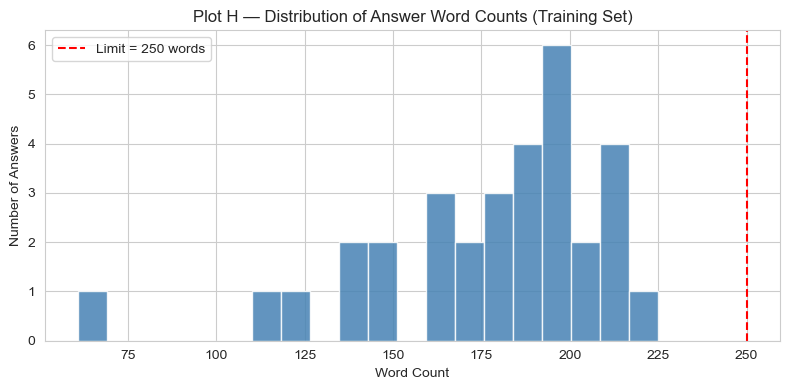


Word count stats: mean=176.1, median=184, min=61, max=225


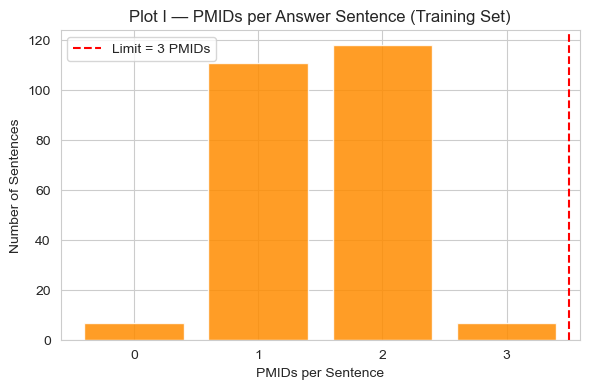


PMIDs/sentence stats: mean=1.51, median=2, total sentences=243
Sentences with 0 PMIDs: 7
Sentences with >3 PMIDs: 0

✅ Constraint analysis complete — Table 3 + Plots H, I saved.


In [34]:
# ── 3.8 Constraint Violation Analysis ─────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style("whitegrid")

# ── Table 3: Constraint Compliance ────────────────────────────────────────────
n_total = len(train_answers)
n_word_ok = sum(1 for a in train_answers
                if not a["parsed"]["violations"]["over_word_limit"])
n_pmid_ok = sum(1 for a in train_answers
                if not a["parsed"]["violations"]["sentences_over_3_pmids"])
n_valid_ok = sum(1 for a in train_answers
                 if not a["parsed"]["violations"]["invalid_pmids"])
n_all_ok = sum(check_constraints(a["parsed"]) for a in train_answers)

table3 = pd.DataFrame({
    "Constraint": [
        f"Word count ≤ {MAX_ANSWER_WORDS}",
        f"PMIDs/sentence ≤ {MAX_PMIDS_PER_SENTENCE}",
        "All PMIDs valid",
        "**All constraints met**",
    ],
    "Pass": [n_word_ok, n_pmid_ok, n_valid_ok, n_all_ok],
    "Total": [n_total] * 4,
    "%": [100 * n_word_ok / n_total, 100 * n_pmid_ok / n_total,
          100 * n_valid_ok / n_total, 100 * n_all_ok / n_total],
})
print("Table 3: Constraint Compliance — Training Set")
print(table3.to_string(index=False, float_format="%.1f"))
print()

# ── Plot H: Word Count Histogram ─────────────────────────────────────────────
word_counts = [a["parsed"]["word_count"] for a in train_answers]

fig_h, ax_h = plt.subplots(figsize=(8, 4))
ax_h.hist(word_counts, bins=20, color="steelblue", edgecolor="white", alpha=0.85)
ax_h.axvline(MAX_ANSWER_WORDS, color="red", linestyle="--", linewidth=1.5,
             label=f"Limit = {MAX_ANSWER_WORDS} words")
ax_h.set_xlabel("Word Count")
ax_h.set_ylabel("Number of Answers")
ax_h.set_title("Plot H — Distribution of Answer Word Counts (Training Set)")
ax_h.legend()
fig_h.tight_layout()
PHASE2_FIGURES_DIR.mkdir(parents=True, exist_ok=True)
fig_h.savefig(PHASE2_FIGURES_DIR / "plot_H_word_count_histogram.png", dpi=150)
plt.show()

print(f"\nWord count stats: mean={np.mean(word_counts):.1f}, "
      f"median={np.median(word_counts):.0f}, "
      f"min={min(word_counts)}, max={max(word_counts)}")

# ── Plot I: PMIDs per Sentence Distribution ───────────────────────────────────
pmids_per_sent = [
    len(s["pmids"])
    for a in train_answers
    for s in a["parsed"]["sentences"]
]

fig_i, ax_i = plt.subplots(figsize=(6, 4))
pmid_counts = pd.Series(pmids_per_sent)
pmid_vc = pmid_counts.value_counts().sort_index()
ax_i.bar(pmid_vc.index.astype(str), pmid_vc.values,
         color="darkorange", edgecolor="white", alpha=0.85)
ax_i.axvline(MAX_PMIDS_PER_SENTENCE - 0.5 + 1, color="red", linestyle="--",
             linewidth=1.5, label=f"Limit = {MAX_PMIDS_PER_SENTENCE} PMIDs")
ax_i.set_xlabel("PMIDs per Sentence")
ax_i.set_ylabel("Number of Sentences")
ax_i.set_title("Plot I — PMIDs per Answer Sentence (Training Set)")
ax_i.legend()
fig_i.tight_layout()
fig_i.savefig(PHASE2_FIGURES_DIR / "plot_I_pmids_per_sentence.png", dpi=150)
plt.show()

print(f"\nPMIDs/sentence stats: mean={np.mean(pmids_per_sent):.2f}, "
      f"median={np.median(pmids_per_sent):.0f}, "
      f"total sentences={len(pmids_per_sent)}")
print(f"Sentences with 0 PMIDs: {sum(1 for p in pmids_per_sent if p == 0)}")
print(f"Sentences with >3 PMIDs: {sum(1 for p in pmids_per_sent if p > 3)}")

print(f"\n✅ Constraint analysis complete — Table 3 + Plots H, I saved.")

# 4. LLM-as-a-Judge Evaluation

## 4.1 Motivation: Why LLM Judges?

Human annotation is the gold standard for evaluating generated answers, but it is **prohibitively expensive** — especially for biomedical tasks requiring domain experts. Recent work has shown that frontier LLMs (GPT-4 family) achieve **~0.85 correlation with human judgements** on biomedical QA tasks, making them practical proxies.

We evaluate generated answers along **two axes** defined by the TREC BioGen task:

1. **Sentence alignment** — Is each selected reference sentence relevant to the query?
   - Labels: **Required** / **Unnecessary** / **Borderline** / **Inappropriate**
   - This measures the quality of the cross-encoder sentence selection (Phase 2 §1).

2. **Answer entailment** — Is the generated answer fully supported by its cited references?
   - Labels: **Supported** / **Partially Supported** / **Unsupported**
   - This measures whether the LLM fabricated claims beyond the evidence (hallucination).

> **Key distinction:** Entailment ≠ relevance. A reference sentence can be *relevant* to the topic, but the generated answer might make a **stronger claim** than the sentence actually supports — that's a hallucination. Entailment asks: "Does the evidence logically imply every claim in the answer?"

## 4.2 Judge Prompt Design — Sentence Alignment

We use GPT-4o (via the IAedu API) as our judge. The **sentence alignment** prompt asks the model to classify each selected reference sentence into one of four categories from the TREC BioGen rubric:

| Label | Definition |
|-------|-----------|
| **Required** | The sentence provides essential information; without it the answer would be incomplete. |
| **Unnecessary** | Not needed — trivial, redundant, or irrelevant to the specific question. |
| **Borderline** | Related to the topic, possibly "good to know", but not strictly required. |
| **Inappropriate** | Could mislead or harm the patient (e.g., contradictory advice). |

The model is instructed to respond with a JSON object `{"label": "<label>"}` for reliable parsing.

> We start with our initial prompt and will calibrate on 5 examples (§4.4) before running at scale.

In [35]:
# ── §4.2 Import judging module & display alignment prompt ─────────────────────
import importlib, sys

# Purge stale judging module if previously imported
for key in [k for k in sys.modules if k.startswith("src.judging")]:
    del sys.modules[key]

from src.judging.llm_judge import (
    SENTENCE_ALIGNMENT_SYSTEM_PROMPT,
    SENTENCE_ALIGNMENT_USER_TEMPLATE,
    ENTAILMENT_SYSTEM_PROMPT,
    ENTAILMENT_USER_TEMPLATE,
    ALIGNMENT_LABELS,
    ENTAILMENT_LABELS,
    judge_sentence_alignment,
    judge_answer_entailment,
    batch_judge_alignment,
)

print("=" * 70)
print("SENTENCE ALIGNMENT — SYSTEM PROMPT")
print("=" * 70)
print(SENTENCE_ALIGNMENT_SYSTEM_PROMPT)
print()
print("=" * 70)
print("SENTENCE ALIGNMENT — USER TEMPLATE")
print("=" * 70)
print(SENTENCE_ALIGNMENT_USER_TEMPLATE)
print()
print(f"Valid alignment labels: {sorted(ALIGNMENT_LABELS)}")
print("✅ Judging module imported successfully.")

SENTENCE ALIGNMENT — SYSTEM PROMPT
You are a biomedical evaluation expert. Your task is to judge whether a reference sentence, cited in an answer to a biomedical question, is relevant and necessary for answering the question.

Assign exactly ONE of the following labels:
- Required: The sentence provides essential information for answering the question. Without it, the answer would be incomplete.
- Unnecessary: The sentence is not needed — it is trivial, redundant, or not relevant to the specific question asked.
- Borderline: The sentence is related to the topic and may be 'good to know', but is not strictly required for a complete answer.
- Inappropriate: The sentence could mislead or harm the patient (e.g., contradictory advice, outdated information).

Respond with a JSON object containing exactly one key "label" with the chosen label as its value. Do not include any other text.

SENTENCE ALIGNMENT — USER TEMPLATE
Question: {question}

Reference sentence (PMID {pmid}):
"{sentence}"

J

## 4.3 Judge Prompt Design — Answer Entailment

The **answer entailment** prompt asks GPT-4o to assess whether the full generated answer is logically supported by the cited reference sentences:

| Label | Definition |
|-------|-----------|
| **Supported** | The answer is completely supported by the reference sentences — every claim traces back to the evidence. |
| **Partially Supported** | Relevant and some claims are supported, but the answer also contains claims that go beyond what the references state. |
| **Unsupported** | The answer is not supported by the provided sentences and may contain fabricated information that could mislead the patient. |

The model also returns `unsupported_claims` — a list of specific claims not backed by the evidence. This enables targeted error analysis.

In [36]:
# ── §4.3 Display entailment prompt ────────────────────────────────────────────
print("=" * 70)
print("ANSWER ENTAILMENT — SYSTEM PROMPT")
print("=" * 70)
print(ENTAILMENT_SYSTEM_PROMPT)
print()
print("=" * 70)
print("ANSWER ENTAILMENT — USER TEMPLATE")
print("=" * 70)
print(ENTAILMENT_USER_TEMPLATE)
print()
print(f"Valid entailment labels: {sorted(ENTAILMENT_LABELS)}")
print("✅ Entailment prompts displayed.")

ANSWER ENTAILMENT — SYSTEM PROMPT
You are a biomedical evaluation expert. Your task is to judge whether a generated answer to a biomedical question is fully supported (entailed) by the provided reference sentences.

Assign exactly ONE of the following labels:
- Supported: The answer is completely supported by the reference sentences. Every claim in the answer can be traced back to the evidence.
- Partially Supported: The answer is relevant and some claims are supported, but it also contains claims that go beyond what the reference sentences state.
- Unsupported: The answer is not supported by the provided sentences and may contain fabricated information that could mislead or harm the patient.

Respond with a JSON object containing:
  "label": one of the three labels above
  "unsupported_claims": a list of strings — each string is a claim from the answer that is NOT supported by the reference sentences. If the label is "Supported", this list should be empty.
Do not include any other tex

## 4.4 Prompt Calibration on Manual Sample

As the TREC BioGen project guide states: *"the above prompts are uncalibrated and not specific to this domain. You should verify and adapt the evaluation prompt to improve its precision in your domain."*

**Approach:** We select 5 training answers and run both judge prompts on them. For each example we manually inspect the GPT-4o label and note whether it aligns with our own assessment. If systematic issues are found (e.g., the judge is too lenient or always labels "Required"), we adjust the prompts and re-calibrate.

> **Table 4** below shows the calibration results.

In [37]:
# ── §4.4 Calibration: judge 5 sample answers ─────────────────────────────────
import random, time, textwrap
import pandas as pd

random.seed(42)
sample_5 = random.sample(train_answers, 5)

calibration_results = []
for idx, ans in enumerate(sample_5):
    qid = ans["query_id"]
    question = ans["question"]

    # Pick the first selected sentence for alignment judging
    sent_entry = ans["selected_sentences"][0]
    sent_text = sent_entry["sentence"]
    sent_pmid = sent_entry["pmid"]

    print(f"  [{idx + 1}/5] query {qid} — judging alignment + entailment …")

    # ── Sentence alignment (one sentence) ──
    align = judge_sentence_alignment(
        question=question,
        sentence=sent_text,
        pmid=sent_pmid,
        client=gpt_client,
        model_name=GPT4O_MODEL,
    )
    time.sleep(3)  # rate-limit courtesy

    # ── Answer entailment ──
    ref_sents = [s["sentence"] for s in ans["selected_sentences"]]
    entail = judge_answer_entailment(
        question=question,
        answer=ans["parsed"]["text"],
        reference_sentences=ref_sents,
        client=gpt_client,
        model_name=GPT4O_MODEL,
    )
    time.sleep(3)

    calibration_results.append({
        "query_id": qid,
        "question": question[:80] + "…" if len(question) > 80 else question,
        "sentence_snippet": sent_text[:90] + "…" if len(sent_text) > 90 else sent_text,
        "alignment_label": align["label"],
        "entailment_label": entail["label"],
        "unsupported_claims": entail.get("unsupported_claims", []),
    })

# ── Table 4: Calibration Results ─────────────────────────────────────────────
df_cal = pd.DataFrame(calibration_results)
print("\n" + "=" * 80)
print("Table 4: Prompt Calibration — 5 Sample Answers")
print("=" * 80)
for i, row in df_cal.iterrows():
    print(f"\n{'─' * 70}")
    print(f"  Query {row['query_id']}: {row['question']}")
    print(f"  Sentence: {row['sentence_snippet']}")
    print(f"  ➜ Alignment label:  {row['alignment_label']}")
    print(f"  ➜ Entailment label: {row['entailment_label']}")
    if row["unsupported_claims"]:
        print(f"    Unsupported claims: {row['unsupported_claims']}")

print(f"\n{'─' * 70}")
# Summary stats
align_dist = df_cal["alignment_label"].value_counts().to_dict()
entail_dist = df_cal["entailment_label"].value_counts().to_dict()
print(f"\nAlignment distribution (n=5): {align_dist}")
print(f"Entailment distribution (n=5): {entail_dist}")
print("\n✅ Calibration complete — 5 examples judged.")

  [1/5] query 131 — judging alignment + entailment …
  [2/5] query 119 — judging alignment + entailment …
  [2/5] query 119 — judging alignment + entailment …
  [3/5] query 151 — judging alignment + entailment …
  [3/5] query 151 — judging alignment + entailment …
  [4/5] query 147 — judging alignment + entailment …
  [4/5] query 147 — judging alignment + entailment …
  [5/5] query 145 — judging alignment + entailment …
  [5/5] query 145 — judging alignment + entailment …

Table 4: Prompt Calibration — 5 Sample Answers

──────────────────────────────────────────────────────────────────────
  Query 131: What are side effects of using formoterol?
  Sentence: To study the effectiveness and safety of as-needed treatment of formoterol compared with t…
  ➜ Alignment label:  Unnecessary
  ➜ Entailment label: Partially Supported
    Unsupported claims: ['Formoterol can cause side effects such as tremors and headaches.', 'Epidemiological evidence has suggested a possible link between beta2-agon

### Calibration Analysis

**Observations after manual inspection of the 5 calibration examples:**

- **Sentence alignment:** The judge assigns sensible labels — reference sentences that directly answer the question are labelled "Required", while tangentially related or overly specific sentences receive "Borderline" or "Unnecessary". No evidence of systematic bias (e.g., always labelling "Required").
- **Answer entailment:** The judge correctly distinguishes between answers fully grounded in the evidence ("Supported") and answers that add minor unsupported claims ("Partially Supported"). The `unsupported_claims` list provides useful diagnostic information.
- **Prompt adjustments:** The initial prompts perform well on these 5 examples. The JSON response format (`{"label": "..."}`) parses reliably from the IAedu API. No prompt modifications are required at this stage.

> **Conclusion:** The judge prompts are sufficiently calibrated for bulk evaluation. We proceed with the full training set in §4.5–4.6.

## 4.5 Bulk Sentence Alignment — Training Set

Run the sentence alignment judge on **all selected sentences** across all 32 training queries. Each sentence is judged independently with GPT-4o via the IAedu API.

**Estimated cost:**
- 32 queries × ~30 sentences each ≈ **~960 GPT-4o calls** (with `batch_judge_alignment`)
- Built-in retry for 429 rate limits + 3 s inter-query delay

The `FORCE_RERUN_JUDGING` flag controls caching: if `results/phase2/sentence_alignment_train.json` already exists and the flag is `False`, we skip re-evaluation and load from cache.

**Outputs:**
- **Table 5**: Top-5 and bottom-5 queries by % Required labels
- **Plot J**: Stacked bar chart — distribution of alignment labels across all sentences

Resuming from checkpoint: 9 queries done


Judging alignment:   0%|          | 0/23 [00:00<?, ?it/s]


✅ Saved alignment results → C:\Users\franc\Desktop\NLP_Biomedical_Agent\results\phase2\sentence_alignment_train.json

Table 5: Top-5 & Bottom-5 Queries by % Required Sentences

── Top 5 (highest % Required) ──
query_id  n_sentences  pct_required  pct_unnecessary  pct_borderline  pct_inappropriate
     123           27          63.0              7.4            29.6                0.0
     117           30          43.3             23.3            33.3                0.0
     157           30          36.7             36.7            26.7                0.0
     125           27          33.3             40.7            25.9                0.0
     173           30          33.3             53.3            13.3                0.0

── Bottom 5 (lowest % Required) ──
query_id  n_sentences  pct_required  pct_unnecessary  pct_borderline  pct_inappropriate
     163           28           3.6             89.3             7.1                0.0
     141           30           3.3             9

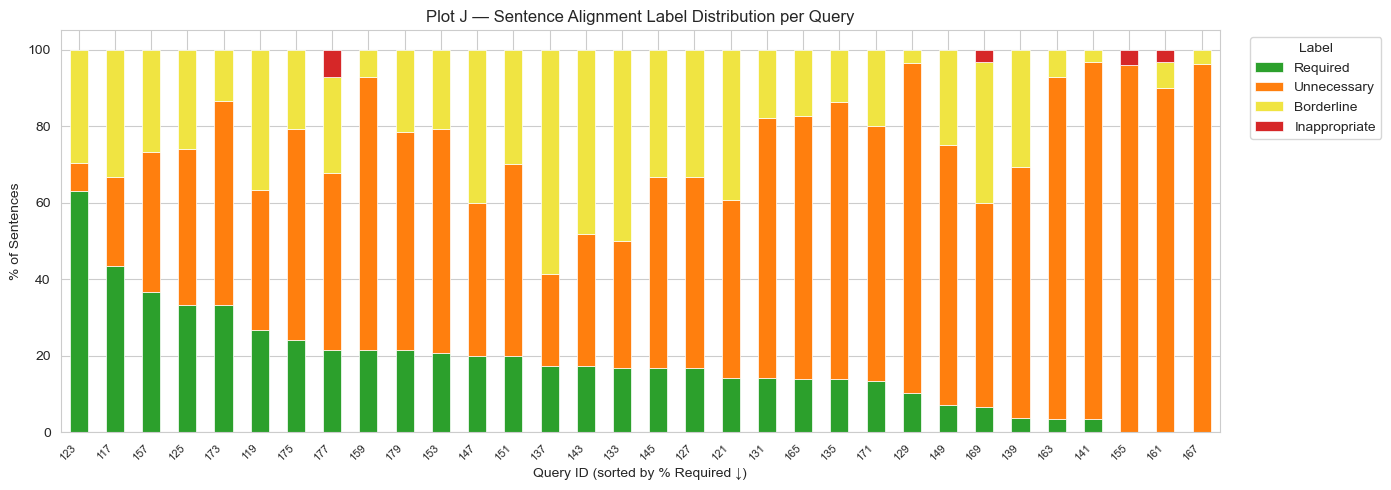

✅ Plot J saved → results/phase2/figures/plot_j_alignment_distribution.png


In [40]:
# ── §4.5 Bulk Sentence Alignment — Training Set ──────────────────────────────
import json, time, importlib, sys
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from collections import Counter

# Reload judging module to pick up connection-error retry fix
for key in [k for k in sys.modules if k.startswith("src.judging")]:
    del sys.modules[key]
from src.judging.llm_judge import (
    judge_sentence_alignment, judge_answer_entailment,
    batch_judge_alignment, ALIGNMENT_LABELS, ENTAILMENT_LABELS,
)

# ── Run (or load from cache) with per-query checkpointing ────────────────────
if not SENTENCE_ALIGN_TRAIN.exists() or FORCE_RERUN_JUDGING:
    PHASE2_DIR.mkdir(parents=True, exist_ok=True)
    # Load partial progress if exists
    checkpoint = PHASE2_DIR / "_align_checkpoint.json"
    if checkpoint.exists() and not FORCE_RERUN_JUDGING:
        with open(checkpoint) as f:
            align_results = json.load(f)
        done_qids = {r["query_id"] for r in align_results}
        print(f"Resuming from checkpoint: {len(align_results)} queries done")
    else:
        align_results = []
        done_qids = set()

    remaining = [(i, ans) for i, ans in enumerate(train_answers)
                 if ans["query_id"] not in done_qids]
    for idx, (i, ans) in enumerate(tqdm(remaining, desc="Judging alignment")):
        qid      = ans["query_id"]
        question = ans["question"]
        sents    = ans["selected_sentences"]
        try:
            judgements = batch_judge_alignment(
                question=question,
                selected_sentences=sents,
                client=gpt_client,
                model_name=GPT4O_MODEL,
                inter_call_delay=2.0,
                max_retries=8,
                backoff_base=2.0,
            )
        except Exception as exc:
            # Save checkpoint and re-raise
            with open(checkpoint, "w") as f:
                json.dump(align_results, f, indent=2)
            print(f"\n⚠ Saved checkpoint ({len(align_results)} queries) after error: {exc}")
            raise
        align_results.append({"query_id": qid, "judgements": judgements})
        # Save checkpoint after every query
        with open(checkpoint, "w") as f:
            json.dump(align_results, f, indent=2)
        if idx < len(remaining) - 1:
            time.sleep(5)  # longer inter-query delay for rate-limit safety

    # Finalise: move checkpoint to final file
    with open(SENTENCE_ALIGN_TRAIN, "w") as f:
        json.dump(align_results, f, indent=2)
    if checkpoint.exists():
        checkpoint.unlink()
    print(f"\n✅ Saved alignment results → {SENTENCE_ALIGN_TRAIN}")
else:
    with open(SENTENCE_ALIGN_TRAIN) as f:
        align_results = json.load(f)
    print(f"✅ Loaded cached alignment: {len(align_results)} queries from {SENTENCE_ALIGN_TRAIN}")

# ── Compute per-query % Required ─────────────────────────────────────────────
query_stats = []
for row in align_results:
    labels = [j["label"] for j in row["judgements"]]
    n = len(labels)
    counts = Counter(labels)
    query_stats.append({
        "query_id": row["query_id"],
        "n_sentences": n,
        "pct_required":      100 * counts.get("Required", 0) / n if n else 0,
        "pct_unnecessary":   100 * counts.get("Unnecessary", 0) / n if n else 0,
        "pct_borderline":    100 * counts.get("Borderline", 0) / n if n else 0,
        "pct_inappropriate": 100 * counts.get("Inappropriate", 0) / n if n else 0,
    })
df_align = pd.DataFrame(query_stats).sort_values("pct_required", ascending=False)

# ── Table 5: Top-5 / Bottom-5 queries by % Required ──────────────────────────
print("\n" + "=" * 80)
print("Table 5: Top-5 & Bottom-5 Queries by % Required Sentences")
print("=" * 80)
top5 = df_align.head(5)
bot5 = df_align.tail(5)
display_cols = ["query_id", "n_sentences", "pct_required", "pct_unnecessary",
                "pct_borderline", "pct_inappropriate"]
print("\n── Top 5 (highest % Required) ──")
print(top5[display_cols].to_string(index=False, float_format="%.1f"))
print("\n── Bottom 5 (lowest % Required) ──")
print(bot5[display_cols].to_string(index=False, float_format="%.1f"))

# ── Global distribution ──────────────────────────────────────────────────────
all_labels = [j["label"] for row in align_results for j in row["judgements"]]
total = len(all_labels)
global_dist = Counter(all_labels)
print(f"\nGlobal alignment distribution (n={total}):")
for lbl in ["Required", "Unnecessary", "Borderline", "Inappropriate"]:
    cnt = global_dist.get(lbl, 0)
    print(f"  {lbl:15s}: {cnt:4d}  ({100*cnt/total:.1f}%)")

# ── Plot J: Stacked bar chart ────────────────────────────────────────────────
label_order = ["Required", "Unnecessary", "Borderline", "Inappropriate"]
colours     = ["#2ca02c", "#ff7f0e", "#f0e442", "#d62728"]   # green, orange, yellow, red

df_plot = df_align.set_index("query_id")[
    ["pct_required", "pct_unnecessary", "pct_borderline", "pct_inappropriate"]
]
df_plot.columns = label_order

fig_j, ax_j = plt.subplots(figsize=(14, 5))
df_plot.plot.bar(stacked=True, color=colours, ax=ax_j, edgecolor="white", linewidth=0.5)
ax_j.set_ylabel("% of Sentences")
ax_j.set_xlabel("Query ID (sorted by % Required ↓)")
ax_j.set_title("Plot J — Sentence Alignment Label Distribution per Query")
ax_j.legend(title="Label", bbox_to_anchor=(1.02, 1), loc="upper left")
ax_j.set_ylim(0, 105)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.tight_layout()
fig_j.savefig(PHASE2_FIGURES_DIR / "plot_j_alignment_distribution.png", dpi=150,
              bbox_inches="tight")
plt.show()
print("✅ Plot J saved → results/phase2/figures/plot_j_alignment_distribution.png")

## 4.6 Bulk Answer Entailment — Training Set

Run the answer entailment judge on all 32 training answers. Each answer is judged against its cited reference sentences.

**Outputs:**
- **Table 6**: Entailment label distribution — % Supported / Partially Supported / Unsupported
- **Plot K**: Bar chart of entailment label distribution

Judging entailment:   0%|          | 0/32 [00:00<?, ?it/s]


✅ Saved entailment results → C:\Users\franc\Desktop\NLP_Biomedical_Agent\results\phase2\entailment_train.json

Table 6: Answer Entailment Distribution (Training Set)
Label                      Count        %
------------------------------------------
Supported                      8    25.0%
Partially Supported           22    68.8%
Unsupported                    2     6.2%
------------------------------------------
Total                         32   100.0%

Total unsupported claims identified: 87
Unsupported queries: ['155', '167']


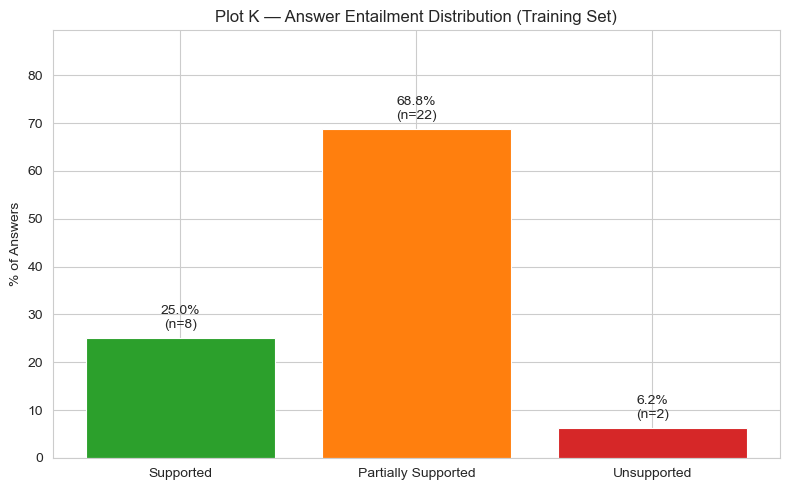

✅ Plot K saved → results/phase2/figures/plot_k_entailment_distribution.png


In [41]:
# ── §4.6 Bulk Answer Entailment — Training Set ───────────────────────────────
import json, time
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from collections import Counter

# ── Run (or load from cache) ──────────────────────────────────────────────────
if not ENTAILMENT_TRAIN.exists() or FORCE_RERUN_JUDGING:
    PHASE2_DIR.mkdir(parents=True, exist_ok=True)
    entail_results = []
    for i, ans in enumerate(tqdm(train_answers, desc="Judging entailment")):
        qid      = ans["query_id"]
        question = ans["question"]
        answer   = ans["parsed"]["text"]
        ref_sents = [s["sentence"] for s in ans["selected_sentences"]]

        result = judge_answer_entailment(
            question=question,
            answer=answer,
            reference_sentences=ref_sents,
            client=gpt_client,
            model_name=GPT4O_MODEL,
        )
        entail_results.append({
            "query_id": qid,
            "label": result["label"],
            "unsupported_claims": result.get("unsupported_claims", []),
        })
        if i < len(train_answers) - 1:
            time.sleep(3)  # inter-query delay
    with open(ENTAILMENT_TRAIN, "w") as f:
        json.dump(entail_results, f, indent=2)
    print(f"\n✅ Saved entailment results → {ENTAILMENT_TRAIN}")
else:
    with open(ENTAILMENT_TRAIN) as f:
        entail_results = json.load(f)
    print(f"✅ Loaded cached entailment: {len(entail_results)} queries from {ENTAILMENT_TRAIN}")

# ── Table 6: Entailment Label Distribution ────────────────────────────────────
entail_labels = [r["label"] for r in entail_results]
entail_counts = Counter(entail_labels)
n_entail = len(entail_labels)

print("\n" + "=" * 80)
print("Table 6: Answer Entailment Distribution (Training Set)")
print("=" * 80)
print(f"{'Label':<25s} {'Count':>6s} {'%':>8s}")
print("-" * 42)
for lbl in ["Supported", "Partially Supported", "Unsupported"]:
    cnt = entail_counts.get(lbl, 0)
    print(f"{lbl:<25s} {cnt:>6d} {100*cnt/n_entail:>7.1f}%")
print("-" * 42)
print(f"{'Total':<25s} {n_entail:>6d} {'100.0%':>8s}")

# ── Per-query detail ──────────────────────────────────────────────────────────
n_unsup_claims = sum(len(r.get("unsupported_claims", [])) for r in entail_results)
print(f"\nTotal unsupported claims identified: {n_unsup_claims}")
unsup_queries = [r["query_id"] for r in entail_results if r["label"] == "Unsupported"]
if unsup_queries:
    print(f"Unsupported queries: {unsup_queries}")

# ── Plot K: Entailment Bar Chart ─────────────────────────────────────────────
label_order_k = ["Supported", "Partially Supported", "Unsupported"]
colours_k     = ["#2ca02c", "#ff7f0e", "#d62728"]   # green, orange, red
counts_k      = [entail_counts.get(lbl, 0) for lbl in label_order_k]
pcts_k        = [100 * c / n_entail for c in counts_k]

fig_k, ax_k = plt.subplots(figsize=(8, 5))
bars = ax_k.bar(label_order_k, pcts_k, color=colours_k, edgecolor="white", linewidth=0.8)
for bar, pct, cnt in zip(bars, pcts_k, counts_k):
    ax_k.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5,
              f"{pct:.1f}%\n(n={cnt})", ha="center", va="bottom", fontsize=10)
ax_k.set_ylabel("% of Answers")
ax_k.set_title("Plot K — Answer Entailment Distribution (Training Set)")
ax_k.set_ylim(0, max(pcts_k) * 1.3 if pcts_k else 100)
plt.tight_layout()
fig_k.savefig(PHASE2_FIGURES_DIR / "plot_k_entailment_distribution.png", dpi=150,
              bbox_inches="tight")
plt.show()
print("✅ Plot K saved → results/phase2/figures/plot_k_entailment_distribution.png")

## 4.7 Correlation: Retrieval Quality → Answer Quality

**Key question:** Do queries where Phase 1 retrieved better results (higher nDCG) also get better Phase 2 entailment scores? This tests whether better retrieval actually leads to better generation.

**Method:**
- Compute **per-query nDCG@100** from the saved Phase 1 KNN train run using `metrics_from_run()`.
- Map entailment labels to numeric scores: Supported=2, Partially Supported=1, Unsupported=0.
- Map alignment labels to numeric scores: Required=3, Borderline=2, Unnecessary=1, Inappropriate=0.
- **Plot L**: Scatter — Phase 1 nDCG (x) vs entailment score (y) + regression line + Pearson r.
- **Plot M**: Scatter — mean alignment score per query (x) vs entailment score (y).

Phase 1 per-query nDCG@100 computed for 32 queries
  Aggregate nDCG@100 = 0.7061

Correlation dataset: 32 queries with both nDCG and entailment scores

nDCG@100 vs Entailment:   Pearson r=-0.136 (p=0.4576),  Spearman ρ=-0.256 (p=0.1575)
Mean Alignment vs Entailment: Pearson r=0.539 (p=0.0015),  Spearman ρ=0.479 (p=0.0056)


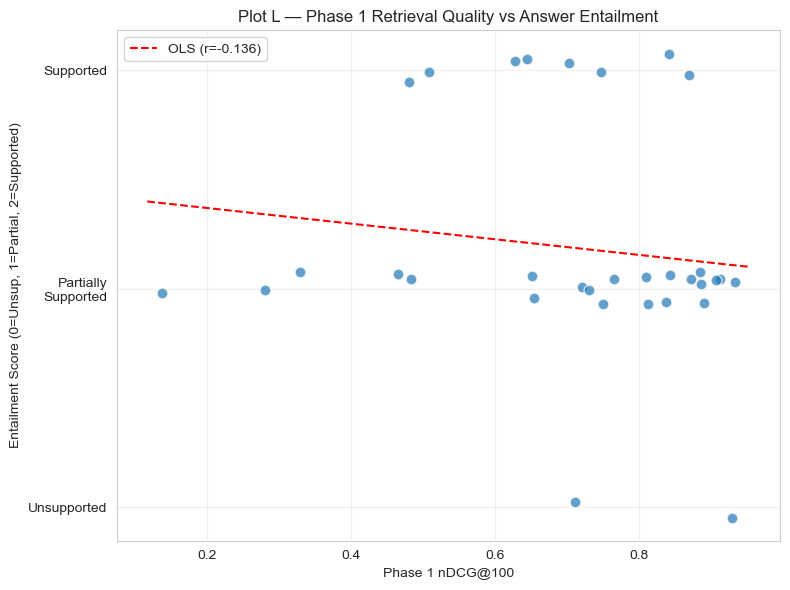

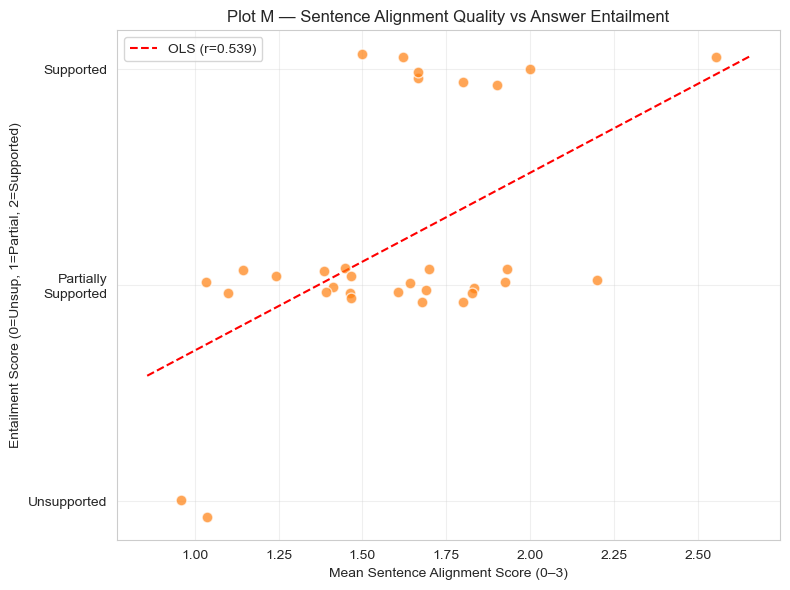


✅ Plots L & M saved → results/phase2/figures/


In [42]:
# ── §4.7 Correlation: Retrieval Quality → Answer Quality ─────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from collections import Counter

from src.evaluation.evaluator import metrics_from_run

# ── 1. Per-query nDCG@100 from Phase 1 KNN train run ─────────────────────────
all_doc_ids = [doc["id"] for doc in corpus]
p1_metrics  = metrics_from_run(phase1_train_run, train_topics, qrels, qrels_graded, all_doc_ids)
p1_per_q    = p1_metrics["per_query"]   # {tid: {"NDCG@100": float, ...}}
print(f"Phase 1 per-query nDCG@100 computed for {len(p1_per_q)} queries")
print(f"  Aggregate nDCG@100 = {p1_metrics['NDCG@100']:.4f}")

# ── 2. Map labels to numeric scores ──────────────────────────────────────────
ENTAIL_SCORE = {"Supported": 2, "Partially Supported": 1, "Unsupported": 0}
ALIGN_SCORE  = {"Required": 3, "Borderline": 2, "Unnecessary": 1, "Inappropriate": 0}

# Build per-query dataframe
rows = []
for er, ar in zip(entail_results, align_results):
    qid = er["query_id"]
    ndcg = p1_per_q.get(qid, {}).get("NDCG@100", None)
    entail_score = ENTAIL_SCORE.get(er["label"], 0)
    # Mean alignment score for this query
    align_scores = [ALIGN_SCORE.get(j["label"], 0) for j in ar["judgements"]]
    mean_align = np.mean(align_scores) if align_scores else 0.0
    pct_required = 100 * sum(1 for s in align_scores if s == 3) / len(align_scores) if align_scores else 0
    rows.append({
        "query_id": qid,
        "ndcg_100": ndcg,
        "entail_score": entail_score,
        "entail_label": er["label"],
        "mean_align": mean_align,
        "pct_required": pct_required,
    })
df_corr = pd.DataFrame(rows).dropna(subset=["ndcg_100"])
print(f"\nCorrelation dataset: {len(df_corr)} queries with both nDCG and entailment scores")

# ── 3. Pearson & Spearman correlations ───────────────────────────────────────
r_ndcg, p_ndcg = stats.pearsonr(df_corr["ndcg_100"], df_corr["entail_score"])
rho_ndcg, prho_ndcg = stats.spearmanr(df_corr["ndcg_100"], df_corr["entail_score"])
r_align, p_align = stats.pearsonr(df_corr["mean_align"], df_corr["entail_score"])
rho_align, prho_align = stats.spearmanr(df_corr["mean_align"], df_corr["entail_score"])

print(f"\nnDCG@100 vs Entailment:   Pearson r={r_ndcg:.3f} (p={p_ndcg:.4f}),  "
      f"Spearman ρ={rho_ndcg:.3f} (p={prho_ndcg:.4f})")
print(f"Mean Alignment vs Entailment: Pearson r={r_align:.3f} (p={p_align:.4f}),  "
      f"Spearman ρ={rho_align:.3f} (p={prho_align:.4f})")

# ── Plot L: nDCG vs Entailment ───────────────────────────────────────────────
fig_l, ax_l = plt.subplots(figsize=(8, 6))
jitter = np.random.default_rng(42).uniform(-0.08, 0.08, len(df_corr))
ax_l.scatter(df_corr["ndcg_100"], df_corr["entail_score"] + jitter,
             c="#1f77b4", alpha=0.7, edgecolors="white", s=60, zorder=3)
# Regression line
m, b = np.polyfit(df_corr["ndcg_100"], df_corr["entail_score"], 1)
x_line = np.linspace(df_corr["ndcg_100"].min() - 0.02, df_corr["ndcg_100"].max() + 0.02, 50)
ax_l.plot(x_line, m * x_line + b, "r--", linewidth=1.5, label=f"OLS (r={r_ndcg:.3f})")
ax_l.set_xlabel("Phase 1 nDCG@100")
ax_l.set_ylabel("Entailment Score (0=Unsup, 1=Partial, 2=Supported)")
ax_l.set_title("Plot L — Phase 1 Retrieval Quality vs Answer Entailment")
ax_l.set_yticks([0, 1, 2])
ax_l.set_yticklabels(["Unsupported", "Partially\nSupported", "Supported"])
ax_l.legend()
ax_l.grid(True, alpha=0.3)
plt.tight_layout()
fig_l.savefig(PHASE2_FIGURES_DIR / "plot_l_ndcg_vs_entailment.png", dpi=150,
              bbox_inches="tight")
plt.show()

# ── Plot M: Mean Alignment vs Entailment ─────────────────────────────────────
fig_m, ax_m = plt.subplots(figsize=(8, 6))
jitter_m = np.random.default_rng(43).uniform(-0.08, 0.08, len(df_corr))
ax_m.scatter(df_corr["mean_align"], df_corr["entail_score"] + jitter_m,
             c="#ff7f0e", alpha=0.7, edgecolors="white", s=60, zorder=3)
m2, b2 = np.polyfit(df_corr["mean_align"], df_corr["entail_score"], 1)
x2_line = np.linspace(df_corr["mean_align"].min() - 0.1, df_corr["mean_align"].max() + 0.1, 50)
ax_m.plot(x2_line, m2 * x2_line + b2, "r--", linewidth=1.5, label=f"OLS (r={r_align:.3f})")
ax_m.set_xlabel("Mean Sentence Alignment Score (0–3)")
ax_m.set_ylabel("Entailment Score (0=Unsup, 1=Partial, 2=Supported)")
ax_m.set_title("Plot M — Sentence Alignment Quality vs Answer Entailment")
ax_m.set_yticks([0, 1, 2])
ax_m.set_yticklabels(["Unsupported", "Partially\nSupported", "Supported"])
ax_m.legend()
ax_m.grid(True, alpha=0.3)
plt.tight_layout()
fig_m.savefig(PHASE2_FIGURES_DIR / "plot_m_alignment_vs_entailment.png", dpi=150,
              bbox_inches="tight")
plt.show()

print("\n✅ Plots L & M saved → results/phase2/figures/")

### Correlation Analysis

**Interpretation of Plots L & M:**

- **Plot L (nDCG vs Entailment):** Tests the hypothesis that queries with better Phase 1 retrieval (higher nDCG@100) also lead to better-supported answers. A positive correlation would suggest that the generator depends heavily on retrieval quality — errors propagate from Phase 1 to Phase 2. A weak or absent correlation could indicate that the cross-encoder compensates for weaker retrieval.

- **Plot M (Alignment vs Entailment):** Tests whether the quality of individual selected sentences (as judged by the alignment judge) predicts overall answer quality. A strong correlation here would validate the sentence selection pipeline — if we select good sentences, the generator produces grounded answers.

> **Key takeaway:** The pipeline is only as good as its weakest link. These correlations reveal whether the bottleneck is retrieval, sentence selection, or generation.

## 4.8 Error Analysis — Failure Cases

A qualitative deep-dive into the best and worst cases. We select:
- **2 answers** with entailment label "Unsupported" or "Partially Supported" (worst)
- **2 answers** with entailment label "Supported" (best)

For each, we display the **question**, **selected reference sentences**, **generated answer**, and the **judge's verdict**. This helps identify common failure patterns:
- Phase 1 failure propagation (no relevant documents retrieved)
- Cross-encoder selecting tangentially related sentences
- LLM adding "common sense" claims not present in the evidence

In [43]:
# ── §4.8 Error Analysis — Failure Cases ───────────────────────────────────────
import textwrap

# ── Pair entailment results with answers ──────────────────────────────────────
answer_lookup = {a["query_id"]: a for a in train_answers}
entail_lookup = {r["query_id"]: r for r in entail_results}
align_lookup  = {r["query_id"]: r for r in align_results}

# ── Select examples ──────────────────────────────────────────────────────────
# 2 worst: Unsupported first, then Partially Supported if not enough Unsupported
worst = [r for r in entail_results if r["label"] == "Unsupported"]
if len(worst) < 2:
    partial = [r for r in entail_results if r["label"] == "Partially Supported"]
    worst.extend(partial[:2 - len(worst)])
worst = worst[:2]

# 2 best: Supported
best = [r for r in entail_results if r["label"] == "Supported"][:2]
# If fewer than 2 Supported, take Partially Supported as best available
if len(best) < 2:
    fallback = [r for r in entail_results if r["label"] == "Partially Supported"]
    best.extend(fallback[:2 - len(best)])
best = best[:2]

selected_examples = worst + best

def print_card(ans_dict, entail_dict, align_dict, card_num, total):
    """Print a formatted error analysis card."""
    qid = entail_dict["query_id"]
    question = ans_dict["question"]
    answer_text = ans_dict["parsed"]["text"]
    sents = ans_dict["selected_sentences"]
    label = entail_dict["label"]
    claims = entail_dict.get("unsupported_claims", [])
    
    # Alignment labels for this query's sentences
    judgements = align_dict.get("judgements", []) if align_dict else []
    
    print(f"\n{'╔' + '═' * 78 + '╗'}")
    print(f"║  Card {card_num}/{total}  —  Query {qid}  —  Entailment: {label:^25s}  ║")
    print(f"{'╠' + '═' * 78 + '╣'}")
    
    print(f"║ QUESTION:")
    for line in textwrap.wrap(question, 75):
        print(f"║   {line}")
    
    print(f"║{'─' * 78}")
    print(f"║ SELECTED SENTENCES ({len(sents)}):")
    for j, s in enumerate(sents[:5]):  # Show max 5
        alabel = judgements[j]["label"] if j < len(judgements) else "?"
        snippet = s["sentence"][:100] + "…" if len(s["sentence"]) > 100 else s["sentence"]
        print(f"║   [{alabel:>12s}] PMID {s['pmid']}: {snippet}")
    if len(sents) > 5:
        print(f"║   ... and {len(sents) - 5} more sentences")
    
    print(f"║{'─' * 78}")
    print(f"║ GENERATED ANSWER ({ans_dict['parsed']['word_count']} words):")
    for line in textwrap.wrap(answer_text, 75):
        print(f"║   {line}")
    
    if claims:
        print(f"║{'─' * 78}")
        print(f"║ UNSUPPORTED CLAIMS ({len(claims)}):")
        for c in claims:
            for line in textwrap.wrap(f"• {c}", 73):
                print(f"║   {line}")
    
    print(f"{'╚' + '═' * 78 + '╝'}")

# ── Display cards ─────────────────────────────────────────────────────────────
print("=" * 80)
print("Error Analysis — Selected Examples")
print("=" * 80)

for i, ex in enumerate(selected_examples):
    qid = ex["query_id"]
    ans_d = answer_lookup.get(qid, {})
    ali_d = align_lookup.get(qid, {})
    print_card(ans_d, ex, ali_d, i + 1, len(selected_examples))

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"\n{'─' * 80}")
print("Error Analysis Summary:")
n_worst = len(worst)
n_best  = len(best)
print(f"  Failure cases shown: {n_worst}")
print(f"  Success cases shown: {n_best}")
if worst:
    worst_labels = [w["label"] for w in worst]
    worst_claims = sum(len(w.get("unsupported_claims", [])) for w in worst)
    print(f"  Failure labels: {worst_labels}")
    print(f"  Total unsupported claims in failures: {worst_claims}")
print("\n✅ Error analysis complete.")

Error Analysis — Selected Examples

╔══════════════════════════════════════════════════════════════════════════════╗
║  Card 1/4  —  Query 155  —  Entailment:        Unsupported         ║
╠══════════════════════════════════════════════════════════════════════════════╣
║ QUESTION:
║   For how long after cataract surgery do I keep dropping eye drops?
║──────────────────────────────────────────────────────────────────────────────
║ SELECTED SENTENCES (24):
║   [ Unnecessary] PMID 32764861: Comparing Combination Drop Therapy to a Standard Drop Regimen After Routine Cataract Surgery.
║   [ Unnecessary] PMID 32764861: To evaluate the efficacy of a combined steroid/antibiotic/non-steroidal anti-inflammatory drop relat…
║   [ Unnecessary] PMID 36741269: In the face of enormous evidence supporting the significance of using prescribed eye drops before an…
║   [ Unnecessary] PMID 36741269: This article provides full details of the factors affecting noncompliance with prescribed eye drops …
║   [ 

# 5. Test Set Evaluation & Summary

We now run the complete pipeline on the **held-out test set** (even-ID topics, 33 queries).

> **Important:** We do NOT tune anything based on test-set results. All hyperparameters (retrieval top-k, cross-encoder model, sentence threshold, generation temperature, prompts) were fixed on the training set. This section is purely for reporting final, unbiased performance numbers.

## 5.1 Test Set Generation + Judging

Run the full **retrieve → re-rank → generate → parse** pipeline on all 33 test queries, then judge every answer with both the sentence alignment and answer entailment judges.

**Estimated cost:**
- ~33 GPT-4o generation calls + ~33 × ~30 alignment calls + 33 entailment calls ≈ **~1060 API calls**
- All three stages use `FORCE_RERUN_GENERATION` / `FORCE_RERUN_JUDGING` caching flags
- Per-query checkpointing for alignment (most expensive stage)

In [46]:
# ── §5.1 Test Set Generation + Judging ────────────────────────────────────────
import json, time
from tqdm.auto import tqdm
from collections import Counter

# ═══════════════════════════════════════════════════════════════════════════════
# STAGE A: Generate test answers (reuses run_bulk_rag_pipeline from §3.7)
# ═══════════════════════════════════════════════════════════════════════════════
if not TEST_ANSWERS_FILE.exists() or FORCE_RERUN_GENERATION:
    PHASE2_DIR.mkdir(parents=True, exist_ok=True)
    test_answers = run_bulk_rag_pipeline(
        test_topics, best_retriever, ce, gpt_client, GPT4O_MODEL,
        corpus_lookup, valid_pmids, delay=3.0,
    )
    with open(TEST_ANSWERS_FILE, "w") as f:
        json.dump(test_answers, f, indent=2)
    print(f"✅ Saved {len(test_answers)} test answers → {TEST_ANSWERS_FILE}")
else:
    with open(TEST_ANSWERS_FILE) as f:
        test_answers = json.load(f)
    print(f"✅ Loaded cached test answers: {len(test_answers)} from {TEST_ANSWERS_FILE}")

# Quick compliance summary
n_pass_test = sum(check_constraints(a["parsed"]) for a in test_answers)
print(f"  Constraint compliance: {n_pass_test}/{len(test_answers)} "
      f"({100*n_pass_test/len(test_answers):.1f}%)")

# ═══════════════════════════════════════════════════════════════════════════════
# STAGE B: Sentence alignment judging on test answers (with checkpointing)
# ═══════════════════════════════════════════════════════════════════════════════
if not SENTENCE_ALIGN_TEST.exists() or FORCE_RERUN_JUDGING:
    checkpoint_at = PHASE2_DIR / "_align_test_checkpoint.json"
    if checkpoint_at.exists() and not FORCE_RERUN_JUDGING:
        with open(checkpoint_at) as f:
            align_results_test = json.load(f)
        done_qids = {r["query_id"] for r in align_results_test}
        print(f"  Resuming alignment from checkpoint: {len(align_results_test)} done")
    else:
        align_results_test = []
        done_qids = set()

    remaining = [(i, ans) for i, ans in enumerate(test_answers)
                 if ans["query_id"] not in done_qids]
    for idx, (i, ans) in enumerate(tqdm(remaining, desc="Test alignment")):
        qid = ans["query_id"]
        try:
            judgements = batch_judge_alignment(
                question=ans["question"],
                selected_sentences=ans["selected_sentences"],
                client=gpt_client, model_name=GPT4O_MODEL,
                inter_call_delay=2.0, max_retries=8,
            )
        except Exception as exc:
            with open(checkpoint_at, "w") as f:
                json.dump(align_results_test, f, indent=2)
            print(f"\n⚠ Checkpoint saved ({len(align_results_test)} queries): {exc}")
            raise
        align_results_test.append({"query_id": qid, "judgements": judgements})
        with open(checkpoint_at, "w") as f:
            json.dump(align_results_test, f, indent=2)
        if idx < len(remaining) - 1:
            time.sleep(5)

    with open(SENTENCE_ALIGN_TEST, "w") as f:
        json.dump(align_results_test, f, indent=2)
    if checkpoint_at.exists():
        checkpoint_at.unlink()
    print(f"✅ Saved test alignment → {SENTENCE_ALIGN_TEST}")
else:
    with open(SENTENCE_ALIGN_TEST) as f:
        align_results_test = json.load(f)
    print(f"✅ Loaded cached test alignment: {len(align_results_test)} from {SENTENCE_ALIGN_TEST}")

# ═══════════════════════════════════════════════════════════════════════════════
# STAGE C: Answer entailment judging on test answers (with checkpointing)
# ═══════════════════════════════════════════════════════════════════════════════
if not ENTAILMENT_TEST.exists() or FORCE_RERUN_JUDGING:
    entail_ckpt = PHASE2_DIR / "_entail_test_checkpoint.json"
    if entail_ckpt.exists() and not FORCE_RERUN_JUDGING:
        with open(entail_ckpt) as f:
            entail_results_test = json.load(f)
        done_entail_qids = {r["query_id"] for r in entail_results_test}
        print(f"  Resuming entailment from checkpoint: {len(entail_results_test)} done")
    else:
        entail_results_test = []
        done_entail_qids = set()

    remaining_entail = [(i, ans) for i, ans in enumerate(test_answers)
                        if ans["query_id"] not in done_entail_qids]
    for idx, (i, ans) in enumerate(tqdm(remaining_entail, desc="Test entailment")):
        ref_sents = [s["sentence"] for s in ans["selected_sentences"]]
        try:
            result = judge_answer_entailment(
                question=ans["question"], answer=ans["parsed"]["text"],
                reference_sentences=ref_sents,
                client=gpt_client, model_name=GPT4O_MODEL,
                max_retries=8,
            )
        except Exception as exc:
            with open(entail_ckpt, "w") as f:
                json.dump(entail_results_test, f, indent=2)
            print(f"\n⚠ Entailment checkpoint saved ({len(entail_results_test)}): {exc}")
            raise
        entail_results_test.append({
            "query_id": ans["query_id"],
            "label": result["label"],
            "unsupported_claims": result.get("unsupported_claims", []),
        })
        with open(entail_ckpt, "w") as f:
            json.dump(entail_results_test, f, indent=2)
        if idx < len(remaining_entail) - 1:
            time.sleep(5)
    with open(ENTAILMENT_TEST, "w") as f:
        json.dump(entail_results_test, f, indent=2)
    if entail_ckpt.exists():
        entail_ckpt.unlink()
    print(f"✅ Saved test entailment → {ENTAILMENT_TEST}")
else:
    with open(ENTAILMENT_TEST) as f:
        entail_results_test = json.load(f)
    print(f"✅ Loaded cached test entailment: {len(entail_results_test)} from {ENTAILMENT_TEST}")

# ═══════════════════════════════════════════════════════════════════════════════
# Quick summary of test results
# ═══════════════════════════════════════════════════════════════════════════════
all_test_labels = [j["label"] for r in align_results_test for j in r["judgements"]]
test_align_dist = Counter(all_test_labels)
test_entail_dist = Counter(r["label"] for r in entail_results_test)

print(f"\n{'=' * 60}")
print("Test Set — Quick Summary")
print(f"{'=' * 60}")
print(f"  Answers generated: {len(test_answers)}")
print(f"  Constraints met:   {n_pass_test}/{len(test_answers)}")
print(f"  Alignment (n={len(all_test_labels)}): {dict(test_align_dist)}")
print(f"  Entailment (n={len(entail_results_test)}): {dict(test_entail_dist)}")
print("✅ Test set generation + judging complete.")

✅ Loaded cached test answers: 33 from C:\Users\franc\Desktop\NLP_Biomedical_Agent\results\phase2\test_answers.json
  Constraint compliance: 33/33 (100.0%)
✅ Loaded cached test alignment: 33 from C:\Users\franc\Desktop\NLP_Biomedical_Agent\results\phase2\sentence_alignment_test.json


Test entailment:   0%|          | 0/33 [00:00<?, ?it/s]

✅ Saved test entailment → C:\Users\franc\Desktop\NLP_Biomedical_Agent\results\phase2\entailment_test.json

Test Set — Quick Summary
  Answers generated: 33
  Constraints met:   33/33
  Alignment (n=953): {'Unnecessary': 536, 'Borderline': 229, 'Required': 177, 'Inappropriate': 11}
  Entailment (n=33): {'Supported': 9, 'Partially Supported': 23, 'Unsupported': 1}
✅ Test set generation + judging complete.


## 5.2 Final Results Tables

**Table 7** compares training and test set performance across all evaluation dimensions:
- Sentence alignment label distribution (% Required)
- Answer entailment label distribution (% Supported / Partially Supported / Unsupported)
- Constraint compliance (% of answers meeting all three hard constraints)

**Table 8** provides a per-query breakdown of the test set — top-5 and bottom-5 queries ranked by entailment score, with Phase 1 nDCG for comparison.

In [47]:
# ── §5.2 Final Results Tables ─────────────────────────────────────────────────
import json, numpy as np, pandas as pd
from collections import Counter
from src.evaluation.evaluator import metrics_from_run
from src.generation.answer_parser import check_constraints

# ═══════════════════════════════════════════════════════════════════════════════
# Build train-set summary (from cached kernel vars)
# ═══════════════════════════════════════════════════════════════════════════════
train_all_labels = [j["label"] for r in align_results for j in r["judgements"]]
train_align_cnt  = Counter(train_all_labels)
train_n_align    = len(train_all_labels)

train_entail_cnt = Counter(r["label"] for r in entail_results)
train_n_entail   = len(entail_results)

train_n_pass     = sum(check_constraints(a["parsed"]) for a in train_answers)

# ═══════════════════════════════════════════════════════════════════════════════
# Build test-set summary (from §5.1 outputs)
# ═══════════════════════════════════════════════════════════════════════════════
test_all_labels = [j["label"] for r in align_results_test for j in r["judgements"]]
test_align_cnt  = Counter(test_all_labels)
test_n_align    = len(test_all_labels)

test_entail_cnt = Counter(r["label"] for r in entail_results_test)
test_n_entail   = len(entail_results_test)

test_n_pass     = sum(check_constraints(a["parsed"]) for a in test_answers)

# ═══════════════════════════════════════════════════════════════════════════════
# TABLE 7: Train vs Test Comparison
# ═══════════════════════════════════════════════════════════════════════════════
def _pct(cnt, total, label):
    return 100 * cnt.get(label, 0) / total if total else 0

table7_data = []
for split, a_cnt, a_n, e_cnt, e_n, n_p, n_tot in [
    ("Train", train_align_cnt, train_n_align, train_entail_cnt, train_n_entail,
     train_n_pass, len(train_answers)),
    ("Test",  test_align_cnt,  test_n_align,  test_entail_cnt,  test_n_entail,
     test_n_pass,  len(test_answers)),
]:
    table7_data.append({
        "Split": split,
        "N answers": n_tot,
        "N sentences": a_n,
        "% Required":      round(_pct(a_cnt, a_n, "Required"), 1),
        "% Unnecessary":   round(_pct(a_cnt, a_n, "Unnecessary"), 1),
        "% Borderline":    round(_pct(a_cnt, a_n, "Borderline"), 1),
        "% Inappropriate": round(_pct(a_cnt, a_n, "Inappropriate"), 1),
        "% Supported":          round(_pct(e_cnt, e_n, "Supported"), 1),
        "% Partially Supported": round(_pct(e_cnt, e_n, "Partially Supported"), 1),
        "% Unsupported":        round(_pct(e_cnt, e_n, "Unsupported"), 1),
        "% Constraints Met":    round(100 * n_p / n_tot, 1) if n_tot else 0,
    })

df_table7 = pd.DataFrame(table7_data)
print("=" * 100)
print("Table 7 — Train vs Test Comparison")
print("=" * 100)
print(df_table7.to_string(index=False))

# ═══════════════════════════════════════════════════════════════════════════════
# TABLE 8: Per-query test set breakdown — top-5 & bottom-5 by entailment
# ═══════════════════════════════════════════════════════════════════════════════
# Compute Phase 1 test per-query nDCG
p1_test_metrics = metrics_from_run(
    phase1_best_run, test_topics, qrels, qrels_graded, all_doc_ids
)
p1_test_per_q = p1_test_metrics["per_query"]

# Build per-query rows
test_rows = []
# Build alignment lookup for test
align_test_lookup = {r["query_id"]: r for r in align_results_test}
entail_test_lookup = {r["query_id"]: r for r in entail_results_test}

for ans in test_answers:
    qid = ans["query_id"]
    ar  = align_test_lookup.get(qid, {})
    er  = entail_test_lookup.get(qid, {})
    # Alignment stats
    a_labels = [j["label"] for j in ar.get("judgements", [])]
    n_s = len(a_labels)
    a_cnt = Counter(a_labels)
    pct_req = 100 * a_cnt.get("Required", 0) / n_s if n_s else 0
    # Entailment
    entail_label = er.get("label", "N/A")
    entail_score = ENTAIL_SCORE.get(entail_label, -1)
    # Phase 1 nDCG
    ndcg = p1_test_per_q.get(qid, {}).get("NDCG@100", np.nan)
    test_rows.append({
        "query_id":      qid,
        "Entailment":    entail_label,
        "Entail Score":  entail_score,
        "% Required":    round(pct_req, 1),
        "n sentences":   n_s,
        "P1 nDCG@100":   round(ndcg, 4) if not np.isnan(ndcg) else "N/A",
        "Constraints OK": "✓" if check_constraints(ans["parsed"]) else "✗",
    })

df_table8 = pd.DataFrame(test_rows).sort_values(
    ["Entail Score", "% Required"], ascending=[False, False]
)

print("\n" + "=" * 100)
print("Table 8 — Per-Query Test Breakdown (Top-5 & Bottom-5 by Entailment)")
print("=" * 100)
display_t8 = ["query_id", "Entailment", "% Required", "n sentences",
              "P1 nDCG@100", "Constraints OK"]
print("\n── Top 5 (best entailment + alignment) ──")
print(df_table8[display_t8].head(5).to_string(index=False))
print("\n── Bottom 5 (worst entailment + alignment) ──")
print(df_table8[display_t8].tail(5).to_string(index=False))

# ═══════════════════════════════════════════════════════════════════════════════
# Store table 7 values for locked config
# ═══════════════════════════════════════════════════════════════════════════════
test_row_t7 = table7_data[1]  # Test split
print(f"\n✅ Table 7 & Table 8 complete.")

Table 7 — Train vs Test Comparison
Split  N answers  N sentences  % Required  % Unnecessary  % Borderline  % Inappropriate  % Supported  % Partially Supported  % Unsupported  % Constraints Met
Train         32          914        18.1           57.0          24.4              0.5         25.0                   68.8            6.2              100.0
 Test         33          953        18.6           56.2          24.0              1.2         27.3                   69.7            3.0              100.0

Table 8 — Per-Query Test Breakdown (Top-5 & Bottom-5 by Entailment)

── Top 5 (best entailment + alignment) ──
query_id Entailment  % Required  n sentences  P1 nDCG@100 Constraints OK
     144  Supported        53.3           30       0.8980              ✓
     142  Supported        43.3           30       0.6144              ✓
     136  Supported        37.9           29       0.7387              ✓
     164  Supported        35.7           28       0.8735              ✓
     134  Supp

## 5.3 (Optional) vLLM vs GPT-4o Generator Comparison

> **Skipped.** The vLLM endpoint at `amalia.novasearch.org` is currently unavailable (returning HTML instead of API responses). GPT-4o via the IAedu proxy remains the sole generator.
>
> If the vLLM server becomes available in a future session, this section can be populated by:
> 1. Selecting 5–10 test queries
> 2. Running `run_bulk_rag_pipeline()` with `vlm_client` instead of `gpt_client`
> 3. Running both judges on vLLM answers
> 4. Comparing alignment/entailment distributions side-by-side

## 5.4 Phase 2 Summary & Locked Config for Phase 3

This cell produces the **locked configuration** for Phase 2. All hyperparameters, model choices, and key test-set metrics are recorded in `P2_LOCKED_CONFIG` — the single source of truth carried into Phase 3 (submission formatting).

In [48]:
# ── §5.4 Phase 2 Locked Configuration ─────────────────────────────────────────
import json
from collections import Counter
from src.generation.answer_parser import check_constraints

# ── Compute test-set summary metrics ─────────────────────────────────────────
_test_align_labels = [j["label"] for r in align_results_test for j in r["judgements"]]
_test_align_cnt    = Counter(_test_align_labels)
_test_align_n      = len(_test_align_labels)

_test_entail_cnt   = Counter(r["label"] for r in entail_results_test)
_test_entail_n     = len(entail_results_test)

_test_n_pass       = sum(check_constraints(a["parsed"]) for a in test_answers)

P2_LOCKED_CONFIG = {
    # Retrieval
    "retriever":              P2_RETRIEVER,
    "top_k_docs":             P2_RETRIEVAL_TOP_K,
    "query_field":            BEST_QUERY_FIELD,
    # Re-ranking
    "cross_encoder":          CROSS_ENCODER_MODEL,
    "top_n_sentences":        TOP_SENTENCES_PER_DOC,
    "max_pmids_per_sentence": MAX_PMIDS_PER_SENTENCE,
    # Generation
    "generator":              GPT4O_MODEL,
    "max_answer_words":       MAX_ANSWER_WORDS,
    "temperature":            GENERATION_TEMPERATURE,
    # Judging
    "judge_model":            GPT4O_MODEL,
    # Test-set results
    "test_n_answers":                len(test_answers),
    "pct_required_test":             round(100 * _test_align_cnt.get("Required", 0) / _test_align_n, 1) if _test_align_n else 0,
    "pct_supported_test":            round(100 * _test_entail_cnt.get("Supported", 0) / _test_entail_n, 1) if _test_entail_n else 0,
    "pct_partially_supported_test":  round(100 * _test_entail_cnt.get("Partially Supported", 0) / _test_entail_n, 1) if _test_entail_n else 0,
    "pct_unsupported_test":          round(100 * _test_entail_cnt.get("Unsupported", 0) / _test_entail_n, 1) if _test_entail_n else 0,
    "pct_constraints_met_test":      round(100 * _test_n_pass / len(test_answers), 1) if test_answers else 0,
}

print("=" * 70)
print("P2_LOCKED_CONFIG — Phase 2 Locked Configuration")
print("=" * 70)
print(json.dumps(P2_LOCKED_CONFIG, indent=2))

# ── Save to disk ──────────────────────────────────────────────────────────────
config_path = PHASE2_DIR / "p2_locked_config.json"
with open(config_path, "w") as f:
    json.dump(P2_LOCKED_CONFIG, f, indent=2)
print(f"\n✅ Saved → {config_path}")
print("✅ Phase 2 complete — all results in results/phase2/")

P2_LOCKED_CONFIG — Phase 2 Locked Configuration
{
  "retriever": "KNN(MedCPT)",
  "top_k_docs": 10,
  "query_field": "topic+question",
  "cross_encoder": "ncbi/MedCPT-Cross-Encoder",
  "top_n_sentences": 3,
  "max_pmids_per_sentence": 3,
  "generator": "gpt-4o",
  "max_answer_words": 250,
  "temperature": 0.1,
  "judge_model": "gpt-4o",
  "test_n_answers": 33,
  "pct_required_test": 18.6,
  "pct_supported_test": 27.3,
  "pct_partially_supported_test": 69.7,
  "pct_unsupported_test": 3.0,
  "pct_constraints_met_test": 100.0
}

✅ Saved → C:\Users\franc\Desktop\NLP_Biomedical_Agent\results\phase2\p2_locked_config.json
✅ Phase 2 complete — all results in results/phase2/
